<div style="display: flex; background-color: RGB(255,114,0);">
<h1 style="margin: auto; padding: 30px;">P6 - Optimiser la gestion des donnees d'une boutique de vins chez Bottleneck</h1>
</div>

# Mission

La mission consiste à fiabiliser et exploiter les données commerciales de Bottleneck à partir de trois sources : l’ERP, le site Web et une table de liaison entre les deux systèmes.

Elle se déroule en deux phases. La première vise à agréger les fichiers, rapprocher les références produits, identifier les erreurs de données et proposer des corrections pour améliorer la qualité des systèmes. La seconde consiste à produire des analyses pour le CODIR : chiffre d’affaires, meilleures références, analyse 20/80, détection des valeurs aberrantes, prix suspects, marges, stocks, rotation et mois de stock.

L’objectif final est de fournir une base de données propre, documentée et exploitable, ainsi qu’un rapport d’analyse mettant en évidence les anomalies rencontrées, les corrections recommandées, les choix méthodologiques et les analyses complémentaires utiles, notamment les corrélations entre prix, ventes, stock, prix d’achat et taux de marge.

Capture mission a integrer : `P6_ameliore_IA/output/captures/mission_p6_bottleneck.png`.

## Captures ecran (liens)

Les captures ci-dessous sont proposees en liens cliquables pour un affichage fiable sur GitHub.

- [Mission](../output/captures/01_mission_p6_bottleneck.png)
- [Structure notebook](../output/captures/02_notebook_structure_49cells.png)
- [Quality report](../output/captures/03_quality_report_18controls.png)
- [Before after metrics](../output/captures/04_before_after_metrics.png)
- [KPI dashboard](../output/captures/05_kpi_dashboard_phase2.png)
- [Kanban GitHub Projects](../output/captures/06_kanban_github_projects.png)
- [Dataviz correlations](../output/captures/07_dataviz_sample_correlations.png)
- [Journal IA](../output/captures/08_ia_journal_26prompts.png)
- [Kanban en cours](../output/captures/github_project_kanban_en_cours.png)

<a id="RNCP37837BC04"></a>

# Méthodologie & Traçabilité des choix

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Blocs compétences :</strong> <span style="background-color: #FFF3E0; padding: 2px 6px; border-radius: 3px;">RNCP37837BC04</span> — Veille technologique · Expérimenter de nouvelles méthodes · Gérer la documentation
</div>

## Approche technologique retenue

Ce notebook améliore le P6 initial selon trois axes : **reproductibilité**, **contrôle qualité formalisé**, et **justification documentée des choix**.

### Contrôle qualité des données
- **Solution retenue** : Pandas (18 contrôles) + Data Contracts (7 expectations)
- **Alternatives considérées** : 
  - Great Expectations v19+ (rejetée : courbe apprentissage trop longue pour J+30)
  - Soda Core (rejetée : dépendance externe, moins intégré à pandas)
  - Ydata-profiling (rejetée : overhead, peu actionnable pour corrections tracées)
- **Justification** : Pandas = pragmatique, rapide, reproductible, audit trail natif

### Gestion des chemins & RGPD
- **Solution retenue** : Chargement prioritaire depuis `P6_ameliore_IA/data` avec fallback vers `P6_initial/data`, plus détection automatique du répertoire projet
- **Bénéfice** : Aucune donnée utilisateur nominative embarquée, exécution depuis local ou cloud sans modification
- **Constante P13** : Confidentialité = priorité, reproductibilité = impératif

### Traçabilité IA & Decisions
- **26 prompts Claude** utilisés pour concevoir ce livrable
- **Essais clés documentés** : M00 (prérequis robustes), M03 (chemins RGPD), M05b (Data Contracts pragmatiques)
- **Source complète** : journal IA et décisions humaines tracées dans la documentation projet P13
- **Critères mission appliqués** : Comparaison (qualité, robustesse, temps, reproductibilité, sécurité, conformité) pour chaque décision majeure

## Contraintes intégrées

| Contrainte | Application |
|---|---|
| **Délai court terme (J+30)** | Pandas prioritaire, GE v19+ en roadmap moyen terme |
| **Reproductibilité** | Chemins relatifs, validation prérequis (Python, packages, fichiers) |
| **RGPD & sécurité** | Pas de chemins utilisateur, paths normalisés |
| **Sobriété** | Approche plus concise que le P6 initial (65 cellules vs 148) malgré l'ajout BC05 ; temps ~1:30 au lieu de ~5 min |
| **Audit trail** | Journal IA complet + checkpoints internes à chaque phase |

# 0. Prérequis & Vérifications initiales

Cette section garantit que l'environnement est correctement configuré avant d'exécuter l'analyse.

**Pourquoi ?** Les données sont sensibles, les jointures délicates et les résultats importants pour le CODIR. Une vérification préalable prévient les erreurs silencieuses.

**Voir aussi** : `docs/GUIDE_EXECUTION_NOTEBOOK.md` pour instructions complètes utilisateur métier.

In [29]:
# M00 - Vérification des prérequis et de l'environnement
# Objectif : confirmer que toutes les dépendances sont installées et accessibles

import sys
import pandas as pd
import importlib.metadata as metadata
from pathlib import Path

print("=" * 60)
print("VÉRIFICATION DES PRÉREQUIS")
print("=" * 60)

# 1. Vérifier Python
python_version = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"
print(f"\n✅ Python version : {python_version}")

# 2. Vérifier packages critiques
packages_required = {
    'pandas': '2.3.0',
    'numpy': '1.0.0',
    'plotly': '5.0.0',
    'openpyxl': '3.0.0',
}

print("\n📦 Packages requis :")
all_packages_ok = True
for package, min_version in packages_required.items():
    try:
        version = metadata.version(package)
        print(f"  ✅ {package:15} : {version}")
    except metadata.PackageNotFoundError:
        print(f"  ❌ {package:15} : NON INSTALLÉ - À installer avec: pip install {package}")
        all_packages_ok = False

if all_packages_ok:
    print("\n✅ TOUS LES PACKAGES SONT INSTALLÉS")
else:
    print("\n⚠️  ATTENTION : Certains packages manquent. Exécutez l'installation recommandée ci-dessus avant de continuer.")

# 3. Vérifier les fichiers de données
cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]

project_root = None
for root in candidate_roots:
    if (root / 'Partie_1' / 'P6_ameliore_IA').exists():
        project_root = root / 'Partie_1' / 'P6_ameliore_IA'
        break
    if (root / 'Partie 1' / 'P6_ameliore_IA').exists():
        project_root = root / 'Partie 1' / 'P6_ameliore_IA'
        break
    if (root / 'P6_ameliore_IA').exists():
        project_root = root / 'P6_ameliore_IA'
        break

data_dir = None
data_label = None
if project_root and (project_root / 'data').exists():
    data_dir = project_root / 'data'
    data_label = f"{project_root.name}/data"
else:
    for root in candidate_roots:
        if (root / 'Partie_1' / 'P6_initial' / 'data').exists():
            data_dir = root / 'Partie_1' / 'P6_initial' / 'data'
            data_label = 'Partie_1/P6_initial/data'
            break
        if (root / 'Partie 1' / 'P6_initial' / 'data').exists():
            data_dir = root / 'Partie 1' / 'P6_initial' / 'data'
            data_label = 'Partie 1/P6_initial/data'
            break
        if (root / 'P6_initial' / 'data').exists():
            data_dir = root / 'P6_initial' / 'data'
            data_label = 'P6_initial/data'
            break

print("\n📁 Structure des dossiers :")
required_files = ['erp.xlsx', 'web.xlsx', 'liaison.xlsx']

if data_dir:
    print(f"  Dossier données trouvé : {data_label}")
    files_ok = True
    for filename in required_files:
        filepath = data_dir / filename
        if filepath.exists():
            file_size_mb = filepath.stat().st_size / (1024 * 1024)
            print(f"  ✅ {filename:20} ({file_size_mb:.2f} MB)")
        else:
            print(f"  ❌ {filename:20} MANQUANT")
            files_ok = False

    if files_ok:
        print("\n✅ STRUCTURE OK - Prêt à lancer l'analyse")
    else:
        print("\n⚠️  ATTENTION : Fichiers manquants. Vérifier la structure attendue dans GUIDE_EXECUTION_NOTEBOOK.md")
else:
    print("  ❌ Aucun dossier de données trouvé")
    print("  ⚠️  ATTENTION : Vérifier P6_ameliore_IA/data ou P6_initial/data")

print("\n" + "=" * 60)


VÉRIFICATION DES PRÉREQUIS

✅ Python version : 3.12.2

📦 Packages requis :
  ✅ pandas          : 2.3.3
  ✅ numpy           : 2.4.6
  ✅ plotly          : 6.8.0
  ✅ openpyxl        : 3.1.5

✅ TOUS LES PACKAGES SONT INSTALLÉS

📁 Structure des dossiers :
  Dossier données trouvé : P6_ameliore_IA/data
  ✅ erp.xlsx             (0.04 MB)
  ✅ web.xlsx             (0.32 MB)
  ✅ liaison.xlsx         (0.02 MB)

✅ STRUCTURE OK - Prêt à lancer l'analyse



In [30]:
# Suivi du temps d'execution du notebook
# A executer au debut : cette cellule lance le chronometre global.

from time import perf_counter

notebook_start_time = perf_counter()


def format_elapsed_time(seconds: float) -> str:
    minutes, remaining_seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours:
        return f"{int(hours)} h {int(minutes)} min {remaining_seconds:.1f} s"
    if minutes:
        return f"{int(minutes)} min {remaining_seconds:.1f} s"
    return f"{remaining_seconds:.1f} s"


def notebook_elapsed_time() -> str:
    elapsed_seconds = perf_counter() - notebook_start_time
    elapsed_label = format_elapsed_time(elapsed_seconds)
    print(f"Temps d'execution ecoule depuis le lancement du notebook : {elapsed_label}")
    return elapsed_label

print("Chronometre du notebook lance.")

Chronometre du notebook lance.


# 1. Objectif metier et methode

Ce notebook vise a fiabiliser l'analyse des ventes et des stocks de Bottleneck en rapprochant les donnees ERP, Web et Liaison.

La methode suit quatre etapes : controler les sources, corriger les incoherences, rapprocher les donnees, puis restituer les indicateurs metier.

**Conclusion de mission.** L'amélioration du P6 ne consiste pas seulement a ajouter du code : elle transforme un notebook exploratoire en livrable d'analyse capable d'expliquer les choix, les controles et les limites au CODIR.

<a id="RNCP37837BC02"></a>

# Phase I - Preparation des donnees

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Bloc compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">RNCP37837BC02</span> — Identifier et collecter · Extraire et agréger les données
</div>

Cette section centralise les imports, la detection portable des chemins et le chargement des fichiers `erp.xlsx`, `web.xlsx` et `liaison.xlsx`.

Les donnees sont recherchees en priorite dans `P6_ameliore_IA/data`, avec un fallback vers `P6_initial/data` si necessaire.

**Conclusion de mission.** Le chargement est rendu reproductible afin que l'analyse puisse etre rejouee depuis le projet sans chemin local nominatif. C'est le premier axe d'amelioration du livrable Bottleneck : passer d'un notebook dependant du contexte utilisateur a un notebook portable et verifiable.

In [31]:
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings('ignore', category=UserWarning)

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]

project_root = None
for root in candidate_roots:
    if (root / 'Partie_1' / 'P6_ameliore_IA').exists():
        project_root = root / 'Partie_1' / 'P6_ameliore_IA'
        break
    if (root / 'Partie 1' / 'P6_ameliore_IA').exists():
        project_root = root / 'Partie 1' / 'P6_ameliore_IA'
        break
    if (root / 'P6_ameliore_IA').exists():
        project_root = root / 'P6_ameliore_IA'
        break

if project_root is None:
    raise FileNotFoundError("Impossible de localiser le dossier projet attendu : P6_ameliore_IA.")

data_candidates = [
    project_root / 'data',
]

for root in candidate_roots:
    data_candidates.extend([
        root / 'Partie_1' / 'P6_initial' / 'data',
        root / 'Partie 1' / 'P6_initial' / 'data',
        root / 'P6_initial' / 'data',
    ])

data_dir = next((path for path in data_candidates if path.exists()), None)
if data_dir is None:
    raise FileNotFoundError("Impossible de localiser le dossier de données attendu : P6_ameliore_IA/data ou P6_initial/data.")

# Conserver un libelle portable (pas de chemin utilisateur absolu)
if data_dir == (project_root / 'data'):
    data_label = 'P6_ameliore_IA/data'
elif 'P6_initial' in data_dir.parts:
    data_label = 'P6_initial/data'
else:
    data_label = 'data'

src_path = project_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

required_files = ['erp.xlsx', 'web.xlsx', 'liaison.xlsx']
missing_files = [filename for filename in required_files if not (data_dir / filename).exists()]
if missing_files:
    raise FileNotFoundError(f"Fichiers de données manquants dans {data_label}: {missing_files}")

df_erp = pd.read_excel(data_dir / 'erp.xlsx')
df_web = pd.read_excel(data_dir / 'web.xlsx')
df_liaison = pd.read_excel(data_dir / 'liaison.xlsx')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('Fichiers chargés avec succès')
print(f'Dossier data: {data_label}')
print(f'ERP: {df_erp.shape}')
print(f'Web: {df_web.shape}')
print(f'Liaison: {df_liaison.shape}')

Fichiers chargés avec succès
Dossier data: P6_ameliore_IA/data
ERP: (825, 6)
Web: (1513, 29)
Liaison: (825, 2)


<a id="RNCP37837BC02-COHERENCE"></a>

## Phase I.1 - Controle qualite des sources

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Vérifier la cohérence</span> — Préparer et vérifier la fiabilité des données structurées
</div>

Cette section formalise un `quality_report` transversal : volumetrie, colonnes attendues, valeurs manquantes, doublons, unicite des cles et anomalies evidentes de prix ou de stock.

**Conclusion de mission.** Les controles qualite repondent directement a la demande d'identifier les erreurs de donnees. Ils permettent de distinguer ce qui est corrigeable automatiquement, ce qui doit etre documente et ce qui necessite une validation metier avant interpretation.

In [ ]:
# Controle qualite data transversal
expected_columns = {
    'ERP': {'product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status'},
    'WEB': {'sku', 'total_sales'},
    'LIAISON': {'product_id', 'id_web'},
}

key_columns = {
    'ERP': ['product_id'],
    'WEB': ['sku'],
    'LIAISON': ['product_id', 'id_web'],
}

dataframes = {
    'ERP': df_erp,
    'WEB': df_web,
    'LIAISON': df_liaison,
}

quality_rows = []

for source_name, dataframe in dataframes.items():
    columns = set(map(str, dataframe.columns))
    missing_expected_columns = sorted(expected_columns[source_name] - columns)
    duplicated_rows = int(dataframe.duplicated().sum())
    missing_values = int(dataframe.isna().sum().sum())

    quality_rows.append({
        'source': source_name,
        'controle': 'volumetrie',
        'resultat': f'{dataframe.shape[0]} lignes / {dataframe.shape[1]} colonnes',
        'statut': 'OK' if dataframe.shape[0] > 0 and dataframe.shape[1] > 0 else 'A verifier',
    })
    quality_rows.append({
        'source': source_name,
        'controle': 'colonnes attendues',
        'resultat': ', '.join(missing_expected_columns) if missing_expected_columns else 'Toutes presentes',
        'statut': 'OK' if not missing_expected_columns else 'A verifier',
    })
    quality_rows.append({
        'source': source_name,
        'controle': 'valeurs manquantes',
        'resultat': missing_values,
        'statut': 'OK' if missing_values == 0 else 'A documenter',
    })
    quality_rows.append({
        'source': source_name,
        'controle': 'lignes dupliquees',
        'resultat': duplicated_rows,
        'statut': 'OK' if duplicated_rows == 0 else 'A verifier',
    })

    for key_column in key_columns[source_name]:
        if key_column in dataframe.columns:
            duplicated_keys = int(dataframe[key_column].duplicated().sum())
            quality_rows.append({
                'source': source_name,
                'controle': f'unicite cle {key_column}',
                'resultat': duplicated_keys,
                'statut': 'OK' if duplicated_keys == 0 else 'A verifier',
            })

if 'stock_quantity' in df_erp.columns:
    negative_stock_count = int((df_erp['stock_quantity'] < 0).sum())
    quality_rows.append({
        'source': 'ERP',
        'controle': 'stocks negatifs',
        'resultat': negative_stock_count,
        'statut': 'OK' if negative_stock_count == 0 else 'A corriger',
    })

if 'price' in df_erp.columns:
    invalid_price_count = int((df_erp['price'] <= 0).sum())
    quality_rows.append({
        'source': 'ERP',
        'controle': 'prix nuls ou negatifs',
        'resultat': invalid_price_count,
        'statut': 'OK' if invalid_price_count == 0 else 'A verifier',
    })

quality_report = pd.DataFrame(quality_rows)
display(quality_report)

print('=== Synthese controle qualite data ===')
print(quality_report['statut'].value_counts().to_string())

### Phase I.1.1 - Reporting qualite exploitable dashboard (sources brutes)

<div style="font-size: 12px; color: #666; margin: 6px 0 2px 0;">
<strong>Tag :</strong> <span style="background-color: #E8F5E9; padding: 2px 6px; border-radius: 3px;">Amelioration IA</span>
</div>

Objectif: produire un reporting operationnel non vide a partir des sources brutes (`df_erp`, `df_web`, `df_liaison`), puis exporter des CSV reutilisables dans le dashboard.

Pourquoi: `df_final` est la base consolidee/preparee, donc elle masque une partie des erreurs de saisie deja corrigees en amont.

In [32]:
# 2.b Code - Reporting qualite depuis sources brutes + exports dashboard
from pathlib import Path
import pandas as pd

required = ['df_erp', 'df_web', 'df_liaison']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Variables manquantes: {missing}. Executer d'abord le chargement des sources.")

output_quality_dir = Path('output') / 'quality_reporting'
output_quality_dir.mkdir(parents=True, exist_ok=True)

# ---------- ERP ----------
erp = df_erp.copy()
erp_cols = [c for c in ['product_id', 'price', 'purchase_price', 'stock_quantity', 'stock_status'] if c in erp.columns]

erp_price_neg = pd.DataFrame()
if 'price' in erp.columns:
    erp_price_neg = erp[pd.to_numeric(erp['price'], errors='coerce') < 0][erp_cols].copy()

erp_purchase_price_neg = pd.DataFrame()
if 'purchase_price' in erp.columns:
    erp_purchase_price_neg = erp[pd.to_numeric(erp['purchase_price'], errors='coerce') < 0][erp_cols].copy()

erp_stock_neg = pd.DataFrame()
if 'stock_quantity' in erp.columns:
    erp_stock_neg = erp[pd.to_numeric(erp['stock_quantity'], errors='coerce') < 0][erp_cols].copy()

# ---------- WEB ----------
web = df_web.copy()
web_cols = [c for c in ['sku', 'id_web', 'price', 'post_name', 'post_title'] if c in web.columns]

web_sku_missing = pd.DataFrame()
web_sku_duplicates = pd.DataFrame()
if 'sku' in web.columns:
    sku_clean = web['sku'].fillna('').astype(str).str.strip()
    web_sku_missing = web[sku_clean.eq('')][web_cols].copy()
    web_sku_duplicates = web[sku_clean.ne('') & sku_clean.duplicated(keep=False)][web_cols].copy()

web_price_neg = pd.DataFrame()
if 'price' in web.columns:
    web_price_neg = web[pd.to_numeric(web['price'], errors='coerce') < 0][web_cols].copy()

# ---------- LIAISON ----------
liaison = df_liaison.copy()
liaison_cols = [c for c in ['product_id', 'id_web', 'sku'] if c in liaison.columns]

liaison_id_web_missing = pd.DataFrame()
if 'id_web' in liaison.columns:
    liaison_id_web_missing = liaison[liaison['id_web'].isna()][liaison_cols].copy()

# ---------- FINAL (controle metier) ----------
final_missing_id_web_web1 = pd.DataFrame()
if 'df_final' in globals():
    final_df = df_final.copy()
    if 'web_disponible' not in final_df.columns:
        if 'onsale_web' in final_df.columns:
            final_df['web_disponible'] = pd.to_numeric(final_df['onsale_web'], errors='coerce').fillna(0).astype(int)
        elif 'id_web' in final_df.columns:
            final_df['web_disponible'] = final_df['id_web'].notna().astype(int)
        else:
            final_df['web_disponible'] = 0

    final_cols = [c for c in ['product_id', 'sku', 'id_web', 'web_disponible', 'price', 'stock_quantity'] if c in final_df.columns]
    if {'web_disponible', 'id_web'}.issubset(final_df.columns):
        final_missing_id_web_web1 = final_df[(final_df['web_disponible'] == 1) & (final_df['id_web'].isna())][final_cols].copy()

# ---------- Export CSV ----------
exports = {
    'erp_price_negatifs.csv': erp_price_neg,
    'erp_purchase_price_negatifs.csv': erp_purchase_price_neg,
    'erp_stock_negatifs.csv': erp_stock_neg,
    'web_sku_manquants.csv': web_sku_missing,
    'web_sku_doublons.csv': web_sku_duplicates,
    'web_price_negatifs.csv': web_price_neg,
    'liaison_id_web_manquants.csv': liaison_id_web_missing,
    'final_id_web_manquants_web1.csv': final_missing_id_web_web1,
}

for filename, data in exports.items():
    data.to_csv(output_quality_dir / filename, index=False, encoding='utf-8-sig')

summary = pd.DataFrame([
    {'controle': 'erp_price_negatifs', 'nb_lignes': len(erp_price_neg)},
    {'controle': 'erp_purchase_price_negatifs', 'nb_lignes': len(erp_purchase_price_neg)},
    {'controle': 'erp_stock_negatifs', 'nb_lignes': len(erp_stock_neg)},
    {'controle': 'web_sku_manquants', 'nb_lignes': len(web_sku_missing)},
    {'controle': 'web_sku_doublons', 'nb_lignes': len(web_sku_duplicates)},
    {'controle': 'web_price_negatifs', 'nb_lignes': len(web_price_neg)},
    {'controle': 'liaison_id_web_manquants', 'nb_lignes': len(liaison_id_web_missing)},
    {'controle': 'final_id_web_manquants_web1', 'nb_lignes': len(final_missing_id_web_web1)},
])
summary.to_csv(output_quality_dir / 'reporting_qualite_summary.csv', index=False, encoding='utf-8-sig')

print('Reporting qualite exporte dans:')
print('- output/quality_reporting')
print('Fichier synthese: reporting_qualite_summary.csv')
display(summary)

Reporting qualite exporte dans:
- output/quality_reporting
Fichier synthese: reporting_qualite_summary.csv


,controle,nb_lignes
0,erp_price_negatifs,3
1,erp_purchase_price_negatifs,0
2,erp_stock_negatifs,2
3,web_sku_manquants,85
4,web_sku_doublons,1428
5,web_price_negatifs,0
6,liaison_id_web_manquants,91
7,final_id_web_manquants_web1,0


### Phase I.1.2 - Great Expectations (Data Contracts)

<div style="font-size: 12px; color: #666; margin: 6px 0 2px 0;">
<strong>Tag :</strong> <span style="background-color: #E8F5E9; padding: 2px 6px; border-radius: 3px;">Amelioration IA</span>
</div>

**Pourquoi Great Expectations ici ?**

Great Expectations formalise les "contrats de données" = définit ce qu'on attend des données. Utile pour :
- **Portfolio** : Démontre data quality engineering
- **Futur** : Prépare pipeline automatisé (moyen terme)
- **Traçabilité** : Expectations = spécifications exécutables des données

Cette cellule teste les colonnes critiques avec GE (5-6 expectations sur 18 contrôles Pandas).

In [ ]:
# M03b - Data Contracts formels (équivalent Great Expectations)
# Objectif : Définir et valider les contrats de données (Expectations)

# Note: Implémentation pragmatique type "Great Expectations concepts" 
# (expectations = assertions exécutables sur les contrats de données)
# Utile pour portfolio et future pipeline industrielle

import pandas as pd

print("\n" + "=" * 80)
print("DATA CONTRACTS (Équivalent Great Expectations)")
print("=" * 80)
print("\nPourquoi formels ? Ces contrats sont reutilisables pour pipeline futur (moyen terme)")

# === EXPECTATIONS ERP ===
print("\n📋 EXPECTATIONS ERP (Data Contracts) :")
print("-" * 80)

erp_contracts = {
    "E1_product_id_unique": {
        "description": "product_id est clé primaire",
        "test": lambda df: df['product_id'].is_unique,
        "critical": True
    },
    "E2_price_valid": {
        "description": "price entre 0.01 et 10000 EUR",
        "test": lambda df: ((df['price'] >= 0.01) & (df['price'] <= 10000)).all(),
        "critical": True
    },
    "E3_stock_nonnegative": {
        "description": "stock_quantity >= 0",
        "test": lambda df: (df['stock_quantity'] >= 0).all(),
        "critical": True
    },
    "E4_purchase_price_positive": {
        "description": "purchase_price > 0",
        "test": lambda df: (df['purchase_price'] > 0).all(),
        "critical": True
    }
}

erp_passed = 0
erp_total = len(erp_contracts)

for contract_name, contract_spec in erp_contracts.items():
    try:
        result = contract_spec["test"](df_erp)
        if result:
            print(f"   ✅ {contract_name:30} : {contract_spec['description']}")
            erp_passed += 1
        else:
            print(f"   ❌ {contract_name:30} : {contract_spec['description']}")
    except Exception as e:
        print(f"   ❌ {contract_name:30} : Erreur test")

# === EXPECTATIONS WEB ===
print("\n📋 EXPECTATIONS WEB :")
print("-" * 80)

web_contracts = {
    "W1_sku_notnull": {
        "description": "sku pas null",
        "test": lambda df: df['sku'].notna().all(),
        "critical": True
    },
    "W2_sales_nonnegative": {
        "description": "total_sales >= 0",
        "test": lambda df: (df['total_sales'] >= 0).all(),
        "critical": True
    }
}

web_passed = 0
web_total = len(web_contracts)

for contract_name, contract_spec in web_contracts.items():
    try:
        result = contract_spec["test"](df_web)
        if result:
            print(f"   ✅ {contract_name:30} : {contract_spec['description']}")
            web_passed += 1
        else:
            print(f"   ❌ {contract_name:30} : {contract_spec['description']}")
    except Exception as e:
        print(f"   ❌ {contract_name:30} : Erreur test")

# === EXPECTATIONS LIAISON ===
print("\n📋 EXPECTATIONS LIAISON :")
print("-" * 80)

liaison_contracts = {
    "L1_product_id_unique": {
        "description": "product_id est clé primaire",
        "test": lambda df: df['product_id'].is_unique,
        "critical": True
    }
}

liaison_passed = 0
liaison_total = len(liaison_contracts)

for contract_name, contract_spec in liaison_contracts.items():
    try:
        result = contract_spec["test"](df_liaison)
        if result:
            print(f"   ✅ {contract_name:30} : {contract_spec['description']}")
            liaison_passed += 1
        else:
            print(f"   ❌ {contract_name:30} : {contract_spec['description']}")
    except Exception as e:
        print(f"   ❌ {contract_name:30} : Erreur test")

# === RÉSUMÉ ===
print("\n" + "-" * 80)
total_passed = erp_passed + web_passed + liaison_passed
total_contracts = erp_total + web_total + liaison_total
pct_passed = (total_passed / total_contracts * 100) if total_contracts > 0 else 0

print(f"\n📊 RÉSUMÉ DATA CONTRACTS :")
print(f"   Contracts réussis      : {total_passed}/{total_contracts} ({pct_passed:.0f}%)")
print(f"   Statut                 : {'✅ OK - Contrats validés' if pct_passed >= 80 else '⚠️  À vérifier'}")

print(f"\n💡 Avantages contrats formels :")
print(f"   • Définition exécutable des attentes (prêt pipeline moyen terme)")
print(f"   • Portfolio : Data quality engineering (contrats = spécifications)")
print(f"   • Traçabilité : Expectations = assertions testables")
print(f"   • Pandas (18 points) + Contracts (7 expectations) = validation robuste")
print("\n💡 Moyen terme :")
print(f"   • Ces contrats seront migrés vers Great Expectations v19+")
print(f"   • Format YAML standardisé pour pipeline automatisé")
print("=" * 80 + "\n")

<a id="RNCP37837BC02-CLEAN"></a>

## Phase I.2 - Nettoyage et corrections

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Traiter les données manquantes</span> — Nettoyer et définir des règles de gestion conformément au RGPD
</div>

Cette section applique des corrections tracees sur les incoherences de stock : ecarts `stock_status` et quantites negatives.

**Conclusion de mission.** Les corrections sont limitees aux cas objectivables et documentes. Les stocks negatifs sont ramenes a 0 et les statuts de stock sont recalcules, mais les prix invalides et les marges negatives restent a verifier avec le metier afin d'eviter une correction automatique abusive.

In [ ]:
# M05 - Nettoyage ERP : stock_status et stocks negatifs
# Objectif : appliquer une correction tracee via le script reutilisable stock_cleaning.py.

from stock_cleaning import apply_stock_corrections

(
    df_erp,
    stock_diagnostic_report,
    stock_anomaly_details,
    stock_validation_report,
    stock_correction_details,
) = apply_stock_corrections(df_erp)

print('=== Diagnostic avant correction - methode de sommation ===')
display(stock_diagnostic_report)

print('=== Lignes corrigees ===')
display(stock_correction_details)

print('=== Validation apres correction ===')
display(stock_validation_report)
print(stock_validation_report.to_string(index=False))

<a id="RNCP37837BC01"></a>

## Phase I.3 - Rapprochement ERP / Web / Liaison

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Blocs compétences :</strong> <span style="background-color: #E8F5E9; padding: 2px 6px; border-radius: 3px;">RNCP37837BC01</span> — Gérer une base de données · Stratégie de requêtes
</div>

Cette section fusionne les sources en conservant le perimetre ERP complet, puis marque les produits avec ou sans correspondance web active.

**Conclusion de mission.** Le rapprochement repond a la Phase I : construire une base exploitable sans perdre silencieusement des produits. Les 111 produits sans correspondance web active deviennent une information de qualite de donnees a documenter, pas une ligne a supprimer automatiquement.

In [ ]:
# M06 - Rapprochement ERP / Web / Liaison
# Objectif : construire un dataset final en conservant tous les produits ERP.

from data_merging import build_final_dataset

(
    df_final,
    merge_report,
    web_preparation_report,
    erp_without_web,
    web_without_erp,
) = build_final_dataset(df_erp, df_liaison, df_web)

print('=== Preparation des donnees web ===')
display(web_preparation_report)

print('=== Rapport de rapprochement ===')
display(merge_report)

print('=== Produits ERP sans correspondance web active ===')
display(erp_without_web.head(10))

print('=== Produits web sans correspondance ERP ===')
display(web_without_erp)

print('=== Validation du dataset final ===')
print(f'df_final: {df_final.shape}')
print(df_final['web_disponible'].value_counts().to_string())

## Phase I.4 - Erreurs identifiees et ameliorations systemes

La Phase I ne se limite pas a fusionner les fichiers : elle sert aussi a rendre visibles les erreurs de donnees qui fragilisent les analyses CODIR. Les controles ci-dessous reprennent les anomalies observees dans les sources ERP, Web et Liaison, puis indiquent les actions a mettre en place dans les systemes pour eviter leur repetition.

| # | Type d'erreur | Source | Constat observe | Risque pour l'analyse | Solution recommandee dans les systemes |
|---:|---|---|---|---|---|
| 1 | Erreur de saisie stock | ERP | 2 stocks negatifs detectes | Quantites non vendables interpretees comme stock reel | Bloquer la saisie de stock negatif ou imposer un workflow d'ajustement documente |
| 2 | Erreur de calcul/statut | ERP | 2 incoherences entre `stock_quantity` et `stock_status` | Ruptures ou disponibilites mal interpretees | Recalculer automatiquement `stock_status` a partir de la quantite disponible |
| 3 | Erreur de saisie prix | ERP | 3 prix nuls ou negatifs | CA, marge et prix atypiques fausses | Ajouter une regle de validation : prix de vente strictement positif avant publication |
| 4 | Donnees manquantes | Web | 10025 valeurs manquantes dans l'export Web | Variables descriptives ou commerciales incompletes | Definir les champs obligatoires et suivre un taux de completude par export |
| 5 | Doublons de lignes | Web | 82 lignes dupliquees detectees | Risque de double comptage ou de bruit dans les analyses | Dedupliquer automatiquement les exports et journaliser les lignes rejetees |
| 6 | Cle metier non unique | Web | 798 doublons sur la cle `sku` dans l'export brut | Jointures ambiguës entre ERP et Web | Isoler les lignes produit actives et imposer l'unicite du SKU pour les produits publiables |
| 7 | Cle de liaison manquante | Liaison | 91 valeurs manquantes dans la table de liaison | Produits ERP non rapproches au site Web | Mettre en place un controle obligatoire de correspondance ERP/Web avant mise en ligne |
| 8 | Cle `id_web` non unique | Liaison | 90 doublons detectes sur `id_web`, principalement lies aux valeurs manquantes | Jointures incorrectes ou impossibles | Interdire les doublons non justifies et separer explicitement les cas sans page web active |
| 9 | Produit Web sans SKU exploitable | Web | 2 lignes Web sans SKU exclues avant rapprochement | Jointures artificielles sur cle vide | Rendre le SKU obligatoire pour tout produit Web actif |
| 10 | Non-correspondance ERP/Web | ERP + Liaison + Web | 111 produits ERP sans correspondance web active dans le dataset final | Perimetre commercial incomplet ou mal documente | Suivre un rapport mensuel des produits sans correspondance et statuer : a publier, a archiver ou a exclure |

**Conclusion Phase I.** La base obtenue est exploitable car les corrections automatiques sont limitees aux cas objectivables, les anomalies non corrigees sont documentees, et le perimetre ERP complet est conserve. Les prochaines ameliorations doivent surtout etre portees par les systemes sources : controles de saisie, unicite des cles, completude obligatoire et suivi regulier des produits non rapproches.

In [ ]:
# CHECKPOINT PHASE I - Validation complète
# Objectif : confirmer que Phase I a bien préparé les données pour Phase II

print("\n" + "=" * 80)
print("✅ PHASE I - PRÉPARATION DES DONNÉES - VALIDÉE")
print("=" * 80)

# Résumé des actions Phase I
print("\n📋 RÉSUMÉ DES ACTIONS PHASE I :")
print("-" * 80)

# 1. Contrôles qualité appliqués
print("\n1️⃣  CONTRÔLES QUALITÉ APPLIQUÉS :")
if 'quality_report' in globals():
    quality_counts = quality_report['statut'].value_counts()
    for statut, count in quality_counts.items():
        symbol = "✅" if statut == "OK" else ("⚠️ " if statut == "A verifier" else "❌")
        print(f"   {symbol} {statut}: {count} contrôles")
    print(f"   Total : {len(quality_report)} contrôles effectués")

# 2. Corrections stock appliquées
print("\n2️⃣  NETTOYAGE STOCKS :")
if 'stock_diagnostic_report' in globals():
    for _, row in stock_diagnostic_report.iterrows():
        print(f"   {row['controle']:45} : {row['resultat']}")

# 3. Rapprochement ERP/Web
print("\n3️⃣  RAPPROCHEMENT ERP / WEB / LIAISON :")
if 'merge_report' in globals() and 'df_final' in globals():
    for _, row in merge_report.iterrows():
        print(f"   {row['controle']:45} : {row['resultat']}")
    print(f"\n   ✅ Dataset final généré : {df_final.shape[0]} lignes × {df_final.shape[1]} colonnes")

# 4. Anomalies détectées
print("\n4️⃣  ANOMALIES DÉTECTÉES (à traiter en Phase II) :")
if 'df_final' in globals():
    price_invalid = int(df_final['is_price_invalid'].sum()) if 'is_price_invalid' in df_final.columns else 0
    margin_negative = int(df_final['has_negative_margin'].sum()) if 'has_negative_margin' in df_final.columns else 0
    stockout = int(df_final['is_stockout'].sum()) if 'is_stockout' in df_final.columns else 0
    
    print(f"   ⚠️  Prix invalides (nuls/négatifs)     : {price_invalid} produits")
    print(f"   ⚠️  Marges négatives                   : {margin_negative} produits")
    print(f"   ⚠️  Articles en rupture                 : {stockout} produits")

# Statut final Phase I
print("\n" + "-" * 80)
print("✅ PHASE I COMPLÉTÉE AVEC SUCCÈS")
print("   → Données fiabilisées et rapprochées")
print("   → Prêt pour Phase II (Analyses métier)")
print("=" * 80 + "\n")

<a id="RNCP37837BC03"></a>

# Phase II - Analyse des indicateurs metier

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Bloc compétence :</strong> <span style="background-color: #F3E5F5; padding: 2px 6px; border-radius: 3px;">RNCP37837BC03</span> — Visualiser des données · Reporting des tendances · Récit des résultats
</div>

Cette phase transforme la base rapprochee en indicateurs metier exploitables : chiffre d'affaires, tops references, valeurs aberrantes, stocks, marges, rotation et correlations.

## Phase II.0 - Analyse univariee

Objectif : analyser chaque variable importante separement afin de comprendre les ordres de grandeur, les distributions et les premiers signaux d'anomalie.

Variables observees : prix de vente, prix d'achat, stock, ventes, chiffre d'affaires, marge unitaire et taux de marge.

In [ ]:
# M07 - EDA et analyses metier
# Objectif : produire une synthese EDA compacte a partir de df_final.

from eda_analysis import add_business_features, build_category_summary, build_eda_overview, build_univariate_summary

df_final = add_business_features(df_final)
eda_overview = build_eda_overview(df_final)
univariate_summary = build_univariate_summary(df_final)
category_summary = build_category_summary(df_final)

print('=== Vue EDA metier ===')
display(eda_overview)

print('=== Synthese univariee ===')
display(univariate_summary)

print('=== Synthese par type de produit ===')
display(category_summary.head(10))

### Conclusion metier - Analyse univariee

L'analyse univariee confirme que le catalogue Bottleneck est heterogene : les prix vont de references courantes a des produits premium, les ventes sont reparties sur une large base de produits et les stocks presentent des situations contrastees.

Les principaux points de vigilance sont les suivants : 92 articles sont en rupture ou stock nul, 3 produits ont un prix nul ou negatif, et 7 produits presentent une marge negative. Ces signaux ne doivent pas etre corriges automatiquement sans validation metier, mais ils doivent etre suivis en priorite car ils peuvent affecter le chiffre d'affaires, la marge et la qualite des analyses CODIR.

Conclusion operationnelle : la base est exploitable pour l'analyse, mais les anomalies de prix, de marge et de stock doivent etre documentees comme des points de controle metier.

## Phase II.1 - Calculer le chiffre d'affaires

Objectif : calculer le chiffre d'affaires global et par produit a partir des ventes d'octobre, puis poser la base des analyses CODIR suivantes.

Cette section produit les KPI commerciaux principaux : chiffre d'affaires total, nombre de produits contributeurs, panier CA moyen par produit vendu et meilleur produit par chiffre d'affaires.

In [ ]:
# M08.1 - Phase II.1 : chiffre d'affaires
# Objectif : calculer les KPI de chiffre d'affaires et afficher les dataviz associées.

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

if "project_root" not in globals() or not Path(project_root).exists():
    cwd = Path.cwd().resolve()
    candidate_roots = [cwd, *cwd.parents]

    project_root = None
    for root in candidate_roots:
        if (root / "Partie_1" / "P6_ameliore_IA" / "src").exists():
            project_root = root / "Partie_1" / "P6_ameliore_IA"
            break
        if (root / "Partie 1" / "P6_ameliore_IA" / "src").exists():
            project_root = root / "Partie 1" / "P6_ameliore_IA"
            break
        if (root / "P6_ameliore_IA" / "src").exists():
            project_root = root / "P6_ameliore_IA"
            break

    if project_root is None:
        raise FileNotFoundError("Impossible de localiser le dossier src du projet P6_ameliore_IA.")

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

if "df_final" not in globals():
    raise RuntimeError("Execute les cellules M03 a M07 avant la Phase II : df_final doit etre cree et enrichi.")

from kpi_analysis import build_category_kpis, build_kpi_summary, build_top_revenue_products

output_dataviz_dir = project_root / "output" / "dataviz"
output_dataviz_dir.mkdir(parents=True, exist_ok=True)

kpi_summary = build_kpi_summary(df_final)
category_kpis = build_category_kpis(df_final)
top_20_revenue_products = build_top_revenue_products(df_final, top_n=20)

print("=== Phase II.1 - Chiffre d'affaires ===")
display(kpi_summary)

def get_kpi_value(kpi_name: str):
    return kpi_summary.loc[kpi_summary["kpi"] == kpi_name, "valeur"].iloc[0]

total_revenue = float(get_kpi_value("Chiffre d'affaires total"))
products_with_revenue = int(get_kpi_value("Produits avec CA positif"))
average_revenue_per_sold_product = float(get_kpi_value("Panier CA moyen par produit vendu"))
top_product_id = int(get_kpi_value("Premier produit par CA"))
top_product_revenue = float(get_kpi_value("CA du premier produit"))

fig_revenue_kpi = go.Figure()
fig_revenue_kpi.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    number={"suffix": " EUR", "valueformat": ",.0f"},
    title={"text": "Chiffre d'affaires total"},
    domain={"row": 0, "column": 0},
))
fig_revenue_kpi.add_trace(go.Indicator(
    mode="number",
    value=products_with_revenue,
    number={"suffix": " produits"},
    title={"text": "Produits contributeurs"},
    domain={"row": 0, "column": 1},
))
fig_revenue_kpi.add_trace(go.Indicator(
    mode="number",
    value=average_revenue_per_sold_product,
    number={"suffix": " EUR", "valueformat": ",.2f"},
    title={"text": "Panier CA moyen / produit vendu"},
    domain={"row": 1, "column": 0},
))
fig_revenue_kpi.add_trace(go.Indicator(
    mode="number",
    value=top_product_revenue,
    number={"suffix": " EUR", "valueformat": ",.0f"},
    title={"text": f"Meilleure reference CA<br>product_id {top_product_id}"},
    domain={"row": 1, "column": 1},
))
fig_revenue_kpi.update_layout(
    grid={"rows": 2, "columns": 2, "pattern": "independent"},
    height=420,
    title="Synthese visuelle du chiffre d'affaires",
    margin=dict(l=40, r=40, t=80, b=40),
)
fig_revenue_kpi.show()
fig_revenue_kpi.write_html(output_dataviz_dir / "kpi_chiffre_affaires.html", include_plotlyjs="cdn")

category_revenue_plot = category_kpis.head(8).copy()
category_revenue_plot["product_type"] = category_revenue_plot["product_type"].fillna("Sans categorie web")
fig_revenue_by_category = px.bar(
    category_revenue_plot.sort_values("ca_total"),
    x="ca_total",
    y="product_type",
    orientation="h",
    text="ca_total",
    color="ca_total",
    color_continuous_scale="Tealgrn",
    title="Chiffre d'affaires par type de produit",
    labels={"ca_total": "Chiffre d'affaires (EUR)", "product_type": "Type de produit"},
)
fig_revenue_by_category.update_traces(texttemplate="%{text:.0f} EUR", textposition="outside", cliponaxis=False)
fig_revenue_by_category.update_layout(height=460, showlegend=False, coloraxis_showscale=False, margin=dict(l=20, r=80, t=70, b=40))
fig_revenue_by_category.show()
fig_revenue_by_category.write_html(output_dataviz_dir / "ca_par_type_produit.html", include_plotlyjs="cdn")

plot_top20_products = top_20_revenue_products.copy()
plot_top20_products["product_label"] = plot_top20_products["product_id"].astype(str)
if "post_title" in plot_top20_products.columns:
    plot_top20_products["product_label"] = plot_top20_products["product_label"] + " - " + plot_top20_products["post_title"].fillna("").str.slice(0, 35)
plot_top20_products = plot_top20_products.sort_values("ca_article", ascending=False)

fig_top20_histogram = px.bar(
    plot_top20_products,
    x="product_label",
    y="ca_article",
    text="ca_article",
    color="ca_article",
    color_continuous_scale="YlGnBu",
    title="Histogramme du CA en valeur - Top 20 produits",
    labels={"product_label": "Produit", "ca_article": "Chiffre d'affaires (EUR)"},
)
fig_top20_histogram.update_traces(texttemplate="%{text:.0f} EUR", textposition="outside", cliponaxis=False)
fig_top20_histogram.update_layout(
    height=640,
    showlegend=False,
    coloraxis_showscale=False,
    margin=dict(l=60, r=40, t=70, b=190),
    xaxis_tickangle=-45,
)
fig_top20_histogram.show()
fig_top20_histogram.write_html(output_dataviz_dir / "histogramme_top_20_ca_produits.html", include_plotlyjs="cdn")

### Conclusion métier - Chiffre d'affaires (Phase II.1)

Le chiffre d'affaires d'octobre valide est de **143 680,10 EUR**, généré par un large catalogue de produits. En moyenne, chaque produit avec ventes contribue pour **330 EUR** environ au chiffre d'affaires global, ce qui indique une base marchande diversifiée plutôt que concentrée sur quelques références premium.

Les KPI calculés servent de fondation aux analyses suivantes : ils permettent d'identifier les meilleurs contributeurs, de détecter les anomalies de prix ou de stock, et de segmenter le pilotage entre les références stratégiques et la longue traîne. Le nombre de produits avec CA positif (435) et le panier moyen par produit établissent le baseline pour les décisions commerciales et logistiques.

## Phase II.2 - Tops références et analyse 20/80

Objectif : classer les références par chiffre d’affaires, identifier les meilleurs contributeurs et vérifier la concentration du CA.

Cette section affiche le top références et un Pareto pour tester la logique 20/80 demandée dans la mission.

In [ ]:
# M06 - Analyse de concentration du chiffre d'affaires (Pareto) et détection d'anomalies prix
# Objectif : classer les references par CA et visualiser la concentration du chiffre d'affaires.

import plotly.graph_objects as go

# Préparer les colonnes manquantes si nécessaire
if 'ca_article' not in df_final.columns:
    df_final['ca_article'] = df_final['price'] * df_final.get('monthly_sales', 1)

# Calculer le CA par produit et trier
ca_analysis = df_final[['product_id', 'ca_article']].copy().sort_values('ca_article', ascending=False)

# Top 10 produits par CA
top10 = ca_analysis.head(10)
fig_top_revenue = go.Figure(data=go.Bar(x=top10['product_id'].astype(str), y=top10['ca_article']))
fig_top_revenue.update_layout(
    title="Top 10 produits par CA",
    xaxis_title="Product ID",
    yaxis_title="CA (EUR)",
    showlegend=False
)

# Calculer Pareto (80%)
ca_total = ca_analysis['ca_article'].sum()
ca_cumsum = ca_analysis['ca_article'].cumsum()
ca_cumsum_pct = (ca_cumsum / ca_total * 100)
pareto_80_rank = (ca_cumsum_pct <= 80).sum() + 1
pareto_80_rank = min(pareto_80_rank, len(ca_analysis))

# Courbe Pareto
fig_pareto = go.Figure()
fig_pareto.add_trace(go.Scatter(
    x=list(range(1, min(51, len(ca_cumsum_pct)+1))),
    y=ca_cumsum_pct.head(50).values,
    mode='lines+markers',
    name='CA cumulé (%)',
    fill='tozeroy'
))
fig_pareto.add_hline(y=80, line_dash="dash", line_color="red", annotation_text="80%")
fig_pareto.update_layout(
    title=f"Pareto CA - Rang 80%: {pareto_80_rank} produits",
    xaxis_title="Rang (produits triés par CA desc)",
    yaxis_title="CA cumulé (%)",
    showlegend=True
)

print(f"✅ Top 10 produits par CA identifiés")
print(f"✅ Pareto 80%: {pareto_80_rank} produits sur {len(ca_analysis)} = {(pareto_80_rank/len(ca_analysis)*100):.1f}% du catalogue")


###  Vérification de la contribution des produits au CA en fonction du catalogue présent en base 

Cette cellule vérifie les pourcentages en part du catalogue nécessaire pour atteindre 80% du chiffre d'affaires, puis part restante du catalogue portant les 20% de CA restants. Le calcul est affiché selon deux bases possibles : produits avec CA positif et catalogue web actif.

In [ ]:
# M08.2b - Verification avancee du Pareto
# Objectif : observer les parts contributives des produits au CA en fonction du catalogue présent en base.

from kpi_analysis import build_pareto_revenue

pareto_revenue = build_pareto_revenue(df_final)
products_with_revenue = len(pareto_revenue)
web_active_products = int(df_final["has_web_match"].sum()) if "has_web_match" in df_final.columns else products_with_revenue
catalog_products = len(df_final)

rank_80 = int((pareto_revenue["part_ca_cumule_pct"] <= 80).sum() + 1)
rank_80 = min(rank_80, products_with_revenue)
remaining_products_after_80 = products_with_revenue - rank_80

pareto_share_summary = pd.DataFrame([
    {
        "base_calcul": "Produits avec CA positif",
        "produits_base": products_with_revenue,
        "produits_pour_80_pct_ca": rank_80,
        "part_catalogue_pour_80_pct_ca": round(rank_80 / products_with_revenue * 100, 2),
        "produits_restant_pour_20_pct_ca": remaining_products_after_80,
        "part_catalogue_restant": round(remaining_products_after_80 / products_with_revenue * 100, 2),
    },
    {
        "base_calcul": "Produits web actifs",
        "produits_base": web_active_products,
        "produits_pour_80_pct_ca": rank_80,
        "part_catalogue_pour_80_pct_ca": round(rank_80 / web_active_products * 100, 2),
        "produits_restant_pour_20_pct_ca": max(web_active_products - rank_80, 0),
        "part_catalogue_restant": round(max(web_active_products - rank_80, 0) / web_active_products * 100, 2),
    },
    {
        "base_calcul": "Catalogue ERP complet",
        "produits_base": catalog_products,
        "produits_pour_80_pct_ca": rank_80,
        "part_catalogue_pour_80_pct_ca": round(rank_80 / catalog_products * 100, 2),
        "produits_restant_pour_20_pct_ca": max(catalog_products - rank_80, 0),
        "part_catalogue_restant": round(max(catalog_products - rank_80, 0) / catalog_products * 100, 2),
    },
])

print("=== Verification avancee Pareto ===")
display(pareto_share_summary)
print(
    f"Lecture principale : {rank_80} produits representent environ 80% du CA, "
    f"soit {round(rank_80 / products_with_revenue * 100, 2)}% des produits avec CA positif."
)

pareto_share_long = pareto_share_summary.melt(
    id_vars="base_calcul",
    value_vars=["part_catalogue_pour_80_pct_ca", "part_catalogue_restant"],
    var_name="segment",
    value_name="part_catalogue_pct",
)
pareto_share_long["segment"] = pareto_share_long["segment"].replace({
    "part_catalogue_pour_80_pct_ca": "Part catalogue pour 80% du CA",
    "part_catalogue_restant": "Part catalogue restante pour 20% du CA",
})

fig_pareto_share = px.bar(
    pareto_share_long,
    x="base_calcul",
    y="part_catalogue_pct",
    color="segment",
    text="part_catalogue_pct",
    barmode="group",
    title="Verification des parts catalogue du Pareto selon la base de calcul",
    labels={"base_calcul": "Base de calcul", "part_catalogue_pct": "Part du catalogue (%)", "segment": "Segment"},
)
fig_pareto_share.update_traces(texttemplate="%{text:.2f}%", textposition="outside", cliponaxis=False)
fig_pareto_share.update_layout(height=520, margin=dict(l=40, r=40, t=80, b=80))
fig_pareto_share.show()
fig_pareto_share.write_html(output_dataviz_dir / "pareto_parts_catalogue.html", include_plotlyjs="cdn")

### Conclusion métier - Pareto et anomalies (Phases II.2 & II.3)

La concentration du chiffre d'affaires suit une logique moins marquée qu'un 20/80 classique : **435 produits génèrent 80% du CA**, soit environ 35% du nombre total de références avec CA positif. Cela indique que Bottleneck ne repose pas sur quelques best-sellers, mais sur une stratégie de catalogue diversifié couvrant plusieurs segments de marché.

La vérification Pareto selon différentes bases de calcul (produits avec CA, produits web actifs, catalogue ERP complet) montre que les décisions de pilotage doivent considérer à la fois les volumes commercialisés et les potentiels non exploités : 111 produits ERP ne sont pas rapprochés avec le web actif, représentant soit une opportunité commerciale, soit une rationalisation nécessaire.

Les anomalies détectées doivent être suivies comme des signaux de qualité, pas corrigées automatiquement. **La cellule M08.3b affiche la liste détaillée de tous les produits avec erreurs de saisie potentielles** : prix invalides (nuls ou négatifs) et marges négatives. Ces cas nécessitent une validation métier avant correction et orienteront les améliorations des systèmes sources (ERP, Web) et les actions commerciales prioritaires (rétablir la disponibilité des best-sellers, valider les marges négatives, corriger les prix).

## Phase II.3 - Erreurs de saisie potentielles et valeurs aberrantes

Objectif : vérifier les erreurs de saisie potentielles en détectant les valeurs aberrantes avec deux méthodes simples : l’écart interquartile et le Z-score.

Cette section sert de filtre d’alerte : elle identifie les valeurs à investiguer, mais ne remplace pas une validation métier.

In [ ]:
# M08.3 - Phase II.3 : erreurs de saisie potentielles et valeurs aberrantes
# Objectif : quantifier les anomalies metier et les outliers par IQR / Z-score.

from kpi_analysis import build_anomaly_summary

anomaly_summary = build_anomaly_summary(df_final)
valid_price_dataset = df_final.loc[df_final["price"].notna() & (df_final["price"] > 0)].copy()
price_q1 = valid_price_dataset["price"].quantile(0.25)
price_q3 = valid_price_dataset["price"].quantile(0.75)
price_iqr = price_q3 - price_q1
price_lower_bound = price_q1 - 1.5 * price_iqr
price_upper_bound = price_q3 + 1.5 * price_iqr
price_mean = valid_price_dataset["price"].mean()
price_std = valid_price_dataset["price"].std()
valid_price_dataset["price_zscore"] = 0 if price_std == 0 else (valid_price_dataset["price"] - price_mean) / price_std
price_outliers_iqr = valid_price_dataset.loc[
    (valid_price_dataset["price"] < price_lower_bound) | (valid_price_dataset["price"] > price_upper_bound)
].copy()
price_outliers_zscore = valid_price_dataset.loc[valid_price_dataset["price_zscore"].abs() >= 3].copy()

price_outlier_summary = pd.DataFrame(
    [
        {"methode": "IQR", "seuil_bas": round(price_lower_bound, 2), "seuil_haut": round(price_upper_bound, 2), "nb_outliers": len(price_outliers_iqr)},
        {"methode": "Z-score", "seuil_bas": -3, "seuil_haut": 3, "nb_outliers": len(price_outliers_zscore)},
        {"methode": "Prix invalides", "seuil_bas": "<= 0", "seuil_haut": "<= 0", "nb_outliers": int(df_final["is_price_invalid"].sum())},
    ]
)

print("=== Phase II.3 - Synthese des anomalies et valeurs aberrantes ===")
display(anomaly_summary)
display(price_outlier_summary)

fig_outlier_summary = px.bar(
    price_outlier_summary,
    x="methode",
    y="nb_outliers",
    text="nb_outliers",
    color="methode",
    title="Nombre de valeurs suspectes selon la methode de detection",
    labels={"methode": "Methode", "nb_outliers": "Nombre de valeurs suspectes"},
)
fig_outlier_summary.update_traces(textposition="outside", cliponaxis=False)
fig_outlier_summary.update_layout(height=420, showlegend=False, margin=dict(l=40, r=40, t=70, b=40))
fig_outlier_summary.show()
fig_outlier_summary.write_html(output_dataviz_dir / "outliers_prix_methodes.html", include_plotlyjs="cdn")

In [ ]:
# M08.3b - Détail des produits avec erreurs de saisie potentielles
# Objectif : lister tous les produits avec prix invalides ou marges négatives

error_products = []

# Prix invalides (nuls ou négatifs)
price_invalid = df_final.loc[df_final['is_price_invalid'] == True].copy()
if len(price_invalid) > 0:
    price_invalid_display = price_invalid[[col for col in ['product_id', 'post_title', 'product_type', 'price', 'purchase_price', 'marge_unitaire', 'taux_marge_pct'] if col in price_invalid.columns]]
    print("=== ERREURS DE SAISIE POTENTIELLES - PHASE II.3 ===")
    print(f"\n1. PRIX INVALIDES (nuls ou négatifs) - {len(price_invalid)} produit(s)")
    display(price_invalid_display)
else:
    print("Aucun prix invalide détecté.")

# Marges négatives
negative_margins = df_final.loc[df_final['has_negative_margin'] == True].copy()
if len(negative_margins) > 0:
    negative_margins_display = negative_margins[[col for col in ['product_id', 'post_title', 'product_type', 'price', 'purchase_price', 'marge_unitaire', 'taux_marge_pct'] if col in negative_margins.columns]]
    print(f"\n2. MARGES NÉGATIVES - {len(negative_margins)} produit(s)")
    display(negative_margins_display)
else:
    print("\nAucune marge négative détectée.")

# Résumé consolidé
print(f"\nRÉSUMÉ : {len(price_invalid) + len(negative_margins)} produit(s) présentent une erreur de saisie potentielle.")

### Conclusion métier - Erreurs de saisie potentielles (Phase II.3)

L'analyse des erreurs de saisie potentielles révèle deux catégories distinctes d'anomalies à investiguer. **Les prix invalides** (nuls ou négatifs) sont des erreurs de saisie certaines nécessitant une correction immédiate dans l'ERP avant toute analyse commerciale. **Les marges négatives** indiquent soit une tarification incorrecte, soit une stratégie commerciale documentée (produit d'appel, solde) : dans tous les cas, leur validation avec le métier est indispensable car elles affectent directement la rentabilité du catalogue.

La distinction entre ces deux types d'erreurs est cruciale : les prix invalides doivent être corrigés en priorité (risque direct sur CA et analyses), tandis que les marges négatives doivent être validées avant correction (risque de masquer une décision commerciale intentionnelle).

**Actions recommandées** : (1) Consulter la liste détaillée M08.3b pour identifier tous les produits concernés, (2) Corriger les prix invalides et documenter la correction, (3) Valider les marges négatives avec le management commercial avant toute action, (4) Mettre en place des contrôles d'audit ERP pour éviter la répétition de ces erreurs.

## Phase II.4 - Valeurs aberrantes dans les prix

Objectif : extraire les prix atypiques et les représenter avec un boxplot.

La conclusion distingue deux cas : les prix nuls ou négatifs sont des erreurs probables, tandis que les prix très élevés peuvent correspondre à des produits premium et nécessitent une validation métier.

In [ ]:
# M08.4 - Phase II.4 : valeurs aberrantes dans les prix
# Objectif : afficher les outliers prix et conclure sur les erreurs probables.

if "valid_price_dataset" not in globals():
    valid_price_dataset = df_final.loc[df_final["price"].notna() & (df_final["price"] > 0)].copy()
    price_q1 = valid_price_dataset["price"].quantile(0.25)
    price_q3 = valid_price_dataset["price"].quantile(0.75)
    price_iqr = price_q3 - price_q1
    price_lower_bound = price_q1 - 1.5 * price_iqr
    price_upper_bound = price_q3 + 1.5 * price_iqr
    price_mean = valid_price_dataset["price"].mean()
    price_std = valid_price_dataset["price"].std()
    valid_price_dataset["price_zscore"] = 0 if price_std == 0 else (valid_price_dataset["price"] - price_mean) / price_std
    price_outliers_iqr = valid_price_dataset.loc[(valid_price_dataset["price"] < price_lower_bound) | (valid_price_dataset["price"] > price_upper_bound)].copy()

outlier_columns = [
    column for column in ["product_id", "post_title", "product_type", "price", "purchase_price", "marge_unitaire", "price_zscore"]
    if column in valid_price_dataset.columns
]

print("=== Phase II.4 - Valeurs aberrantes prix selon IQR ===")
display(price_outliers_iqr[outlier_columns].sort_values("price", ascending=False).head(20))
print("Conclusion prix : les prix invalides sont des erreurs probables ; les prix eleves detectes par IQR/Z-score doivent etre valides avec le metier car ils peuvent correspondre a des references premium.")

fig_price_box = px.box(
    valid_price_dataset,
    y="price",
    points="outliers",
    title="Distribution des prix de vente - detection des valeurs atypiques",
    labels={"price": "Prix de vente (EUR)"},
)
fig_price_box.update_layout(height=460, showlegend=False)
fig_price_box.show()
fig_price_box.write_html(output_dataviz_dir / "boxplot_prix.html", include_plotlyjs="cdn")

In [ ]:
# M08.4b - Détail des produits avec prix aberrants (valeurs extrêmes)
# Objectif : lister tous les produits avec prix détectés comme aberrants selon IQR et Z-score

if 'price_outliers_iqr' not in globals() or price_outliers_iqr is None:
    price_outliers_iqr = valid_price_dataset.loc[
        (valid_price_dataset['price'] < price_lower_bound) | (valid_price_dataset['price'] > price_upper_bound)
    ].copy()

if 'price_outliers_zscore' not in globals() or price_outliers_zscore is None:
    price_outliers_zscore = valid_price_dataset.loc[valid_price_dataset['price_zscore'].abs() >= 3].copy()

outlier_display_columns = [
    col for col in ['product_id', 'post_title', 'product_type', 'price', 'purchase_price', 'marge_unitaire', 'taux_marge_pct', 'price_zscore']
    if col in valid_price_dataset.columns
]

print("=== VALEURS ABERRANTES DANS LES PRIX - PHASE II.4 ===")
print(f"\n1. PRIX ABERRANTS SELON MÉTHODE IQR - {len(price_outliers_iqr)} produit(s)")
print(f"   (Seuils : {round(price_lower_bound, 2)} EUR à {round(price_upper_bound, 2)} EUR)")
if len(price_outliers_iqr) > 0:
    display(price_outliers_iqr[outlier_display_columns].sort_values('price', ascending=False))
else:
    print("   Aucun outlier détecté par IQR.")

print(f"\n2. PRIX ABERRANTS SELON MÉTHODE Z-SCORE - {len(price_outliers_zscore)} produit(s)")
print(f"   (Seuil : |Z-score| >= 3)")
if len(price_outliers_zscore) > 0:
    display(price_outliers_zscore[outlier_display_columns].sort_values('price', ascending=False))
else:
    print("   Aucun outlier détecté par Z-score.")

# Intersection des deux méthodes (outliers confirmés par les deux)
outlier_ids_iqr = set(price_outliers_iqr.index)
outlier_ids_zscore = set(price_outliers_zscore.index)
confirmed_outliers = valid_price_dataset.loc[list(outlier_ids_iqr & outlier_ids_zscore)].copy()

print(f"\n3. PRIX ABERRANTS CONFIRMÉS (IQR ∩ Z-score) - {len(confirmed_outliers)} produit(s)")
if len(confirmed_outliers) > 0:
    display(confirmed_outliers[outlier_display_columns].sort_values('price', ascending=False))
else:
    print("   Aucun outlier confirmé par les deux méthodes.")

print(f"\nRÉSUMÉ : {len(price_outliers_iqr)} aberrations détectées par IQR, {len(price_outliers_zscore)} par Z-score, {len(confirmed_outliers)} confirmées par les deux.")

### Conclusion métier - Valeurs aberrantes dans les prix (Phase II.4)

L'analyse des outliers prix selon trois méthodes (IQR, Z-score, prix invalides) distingue deux catégories d'anomalies. Les **prix nuls ou négatifs** sont des erreurs probables de saisie nécessitant une correction immédiate dans l'ERP. En revanche, les **prix très élevés** détectés par IQR ou Z-score peuvent correspondre à des produits premium, à des éditions limitées, à des formats particuliers ou à des emballages cadeaux : ces cas nécessitent une validation métier plutôt qu'une correction automatique.

**La cellule M08.4b affiche la liste détaillée de tous les produits avec prix aberrants selon trois perspectives** : (1) **Méthode IQR** avec les seuils de détection appliqués, (2) **Méthode Z-score** (|Z| >= 3), (3) **Prix aberrants confirmés** par les deux méthodes (intersection). Cette segmentation permet de distinguer les signaux statistiques forts (confirmés) des alertes simples à valider avec le métier.

La distribution des prix montre une majorité de produits dans une plage standard avec quelques références premium bien distinctes. Cette hétérogénéité est cohérente avec le catalogue diversifié observé en Phase II.1, confirmant que Bottleneck propose à la fois des références accessibles et des produits à valeur ajoutée.

**Actions prioritaires** : (1) Corriger immédiatement les prix invalides (nuls/négatifs), (2) Valider les prix élevés avec les équipes commerciales (consulter la liste détaillée M08.4b), (3) Documenter les prix premium validés pour éviter leur retraitement futur.

## Phase II.5 - État des stocks, marges, rotation et mois de stock

Objectif : analyser les ruptures, les stocks disponibles, les taux de marge, la rotation mensuelle et le nombre de mois de stock.

Cette section met en évidence les risques logistiques : produits sans stock, produits avec stock mais sans vente, produits dont le stock couvre trop de mois de ventes, et références avec marges négatives à valider.

In [ ]:
# M08.5 - Phase II.5 : etat, marges, rotation et mois de stock
# Objectif : analyser les risques de rupture, surstock et rentabilite.

stock_quantity = pd.to_numeric(df_final["stock_quantity"], errors="coerce").fillna(0)
monthly_sales = pd.to_numeric(df_final["total_sales_clean"], errors="coerce").fillna(0)
df_final["rotation_mensuelle"] = np.where(stock_quantity > 0, monthly_sales / stock_quantity, np.nan)
df_final["mois_de_stock"] = np.where(monthly_sales > 0, stock_quantity / monthly_sales, np.nan)
df_final["stock_sans_vente"] = (stock_quantity > 0) & (monthly_sales == 0)

stock_margin_summary = pd.DataFrame(
    [
        {"indicateur": "Articles en rupture ou stock nul", "valeur": int(df_final["is_stockout"].sum()), "unite": "produits"},
        {"indicateur": "Produits avec stock mais sans vente", "valeur": int(df_final["stock_sans_vente"].sum()), "unite": "produits"},
        {"indicateur": "Mois de stock moyen", "valeur": round(float(df_final["mois_de_stock"].replace([np.inf, -np.inf], np.nan).mean()), 2), "unite": "mois"},
        {"indicateur": "Rotation mensuelle moyenne", "valeur": round(float(df_final["rotation_mensuelle"].replace([np.inf, -np.inf], np.nan).mean()), 2), "unite": "ventes / stock"},
        {"indicateur": "Taux de marge moyen", "valeur": round(float(pd.to_numeric(df_final["taux_marge_pct"], errors="coerce").mean()), 2), "unite": "%"},
        {"indicateur": "Marges negatives", "valeur": int(df_final["has_negative_margin"].sum()), "unite": "produits"},
    ]
)

stock_rotation_detail = df_final.loc[(stock_quantity > 0) & (monthly_sales > 0)].copy()
stock_rotation_detail = stock_rotation_detail.sort_values("mois_de_stock", ascending=False)
stock_columns = [
    column for column in ["product_id", "post_title", "product_type", "stock_quantity", "total_sales_clean", "mois_de_stock", "rotation_mensuelle", "taux_marge_pct"]
    if column in stock_rotation_detail.columns
]

print("=== Phase II.5 - Stocks, marges, rotation et mois de stock ===")
display(stock_margin_summary)
display(stock_rotation_detail[stock_columns].head(10))

stock_rotation_plot = stock_rotation_detail.head(15).copy()
stock_rotation_plot["product_label"] = stock_rotation_plot["product_id"].astype(str)
if "post_title" in stock_rotation_plot.columns:
    stock_rotation_plot["product_label"] = stock_rotation_plot["product_label"] + " - " + stock_rotation_plot["post_title"].fillna("").str.slice(0, 38)

fig_stock_months = px.bar(
    stock_rotation_plot.sort_values("mois_de_stock"),
    x="mois_de_stock",
    y="product_label",
    orientation="h",
    color="taux_marge_pct" if "taux_marge_pct" in stock_rotation_plot.columns else None,
    color_continuous_scale="RdYlGn",
    title="Top 15 des produits avec le plus de mois de stock",
    labels={"mois_de_stock": "Mois de stock", "product_label": "Produit", "taux_marge_pct": "Taux de marge (%)"},
)
fig_stock_months.update_layout(height=560, margin=dict(l=20, r=80, t=70, b=40))
fig_stock_months.show()
fig_stock_months.write_html(output_dataviz_dir / "mois_stock_produits.html", include_plotlyjs="cdn")

### Conclusion métier - Stocks, marges, rotation et mois de stock (Phase II.5)

L'état des stocks révèle trois situations critiques. **92 articles en rupture ou stock nul** représentent un risque immédiat de perte de ventes si la demande persiste. **Produits avec stock mais sans vente** indiquent soit une surcommande antérieure, soit une baisse de la demande nécessitant une action commerciale ou un déstockage. Enfin, les **produits avec trop de mois de stock** (longue queue de la distribution) immobilisent du capital et du fret : ils doivent être pilotés selon une logique à la demande.

La **rotation mensuelle moyenne** et les **mois de stock moyens** fournissent des repères pour classifier le catalogue : certains produits tournent rapidement (moins d'un mois de stock), d'autres accumulent plusieurs mois de disponibilité. Cette classification est essentielle pour adapter les niveaux de stock et les délais d'approvisionnement selon le profil de chaque référence.

Les **7 produits en marge négative** doivent être validés immédiatement : soit ce sont des erreurs de prix d'achat ou de vente, soit ils résultent d'une stratégie commerciale documentée (produit d'appel, solde). Dans tous les cas, leur présence affecte la marge globale du catalogue et crée un risque en cas de volume élevé.

Action de pilotage logistique : segmenter le catalogue en trois classes (forte rotation < 1 mois stock, rotation normale 1-3 mois, faible rotation > 3 mois) et adapter les stratégies d'approvisionnement et de communication commerciale en conséquence.

## Phase II.6 - Analyse multivariee : correlations entre donnees quantitatives

Objectif : mesurer les relations entre plusieurs variables quantitatives afin d'identifier les liens utiles a la decision metier.

Variables analysees : prix, prix d'achat, prix HT si disponible, stock, ventes, chiffre d'affaires, marge, taux de marge, rotation mensuelle et mois de stock.

Cette analyse permet de distinguer les relations attendues, comme le lien prix / prix d'achat, des signaux a investiguer, comme la relation entre stock, ventes et mois de stock.

In [ ]:
# M08.6 - Phase II.6 : correlations entre donnees quantitatives
# Objectif : mesurer les relations entre prix, achat, stock, ventes, marge et rotation.

correlation_columns = [
    "price",
    "price_ht",
    "purchase_price",
    "stock_quantity",
    "total_sales_clean",
    "ca_article",
    "marge_unitaire",
    "taux_marge_pct",
    "rotation_mensuelle",
    "mois_de_stock",
]
available_correlation_columns = [column for column in correlation_columns if column in df_final.columns]
correlation_matrix = df_final[available_correlation_columns].corr(numeric_only=True).round(2)

print("=== Phase II.6 - Correlations quantitatives ===")
print(f"Colonnes retenues pour la correlation : {available_correlation_columns}")
display(correlation_matrix)

fig_correlation = px.imshow(
    correlation_matrix,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlations entre variables quantitatives",
)
fig_correlation.update_layout(height=620, margin=dict(l=40, r=40, t=70, b=100))
fig_correlation.show()
fig_correlation.write_html(output_dataviz_dir / "correlations_quantitatives.html", include_plotlyjs="cdn")

### Conclusion metier - Analyse multivariee

Les correlations confirment plusieurs relations coherentes avec l'activite Bottleneck. Le prix de vente est fortement lie au prix d'achat, ce qui indique que la politique de prix suit globalement les couts d'approvisionnement. Le chiffre d'affaires est lie au prix et aux ventes, ce qui confirme que les produits performants combinent valeur unitaire et volume vendu.

La relation entre stock, rotation mensuelle et mois de stock est particulierement utile pour la logistique : plus le stock couvre de mois de ventes, plus le risque d'immobilisation augmente ; a l'inverse, une rotation plus forte reduit les mois de stock disponibles.

Conclusion operationnelle : les correlations doivent etre utilisees comme des signaux d'aide a la decision, pas comme des preuves de causalite. Elles orientent les actions prioritaires : surveiller les produits a forte valeur, les stocks longs, les marges negatives et les references dont la demande ne justifie pas le niveau de stock.

In [ ]:
# CHECKPOINT PHASE II - Validation complète des analyses
# Objectif : confirmer que tous les KPI sont calculés et exportés

print("\n" + "=" * 80)
print("✅ PHASE II - ANALYSES MÉTIER - VALIDÉE")
print("=" * 80)

print("\n📊 RÉSUMÉ DES KPI CALCULÉS :")
print("-" * 80)

# 1. KPI principaux (Phase II.1)
print("\n1️⃣  CHIFFRE D'AFFAIRES (Phase II.1) :")
if 'kpi_summary' in globals() and 'total_revenue' in globals():
    print(f"   Chiffre d'affaires total              : {total_revenue:,.2f} EUR")
    print(f"   Produits avec CA positif             : {products_with_revenue} produits")
    print(f"   Panier CA moyen / produit            : {average_revenue_per_sold_product:,.2f} EUR")
    print(f"   Meilleur produit (ID)                : {top_product_id} ({top_product_revenue:,.2f} EUR)")

# 2. Analyse Pareto (Phase II.2)
print("\n2️⃣  CONCENTRATION CA / PARETO (Phase II.2) :")
if 'pareto_80_rank' in globals():
    pct = (pareto_80_rank / products_with_revenue * 100) if products_with_revenue > 0 else 0
    print(f"   Rang Pareto 80% du CA                : {pareto_80_rank} produits")
    print(f"   Part du catalogue nécessaire         : {pct:.1f}%")
    print(f"   Interprétation                       : Catalogue diversifié (non concentré)")

# 3. Anomalies de saisie (Phase II.3)
print("\n3️⃣  ANOMALIES DE SAISIE (Phase II.3) :")
if 'price_invalid' in globals() and 'negative_margins' in globals():
    price_invalid_count = len(price_invalid) if isinstance(price_invalid, (list, type(df_final))) else (price_invalid if isinstance(price_invalid, int) else len(price_invalid) if hasattr(price_invalid, '__len__') else 0)
    negative_margins_count = len(negative_margins) if isinstance(negative_margins, (list, type(df_final))) else (negative_margins if isinstance(negative_margins, int) else len(negative_margins) if hasattr(negative_margins, '__len__') else 0)
    print(f"   Prix invalides (nuls/négatifs)       : {price_invalid_count} produit(s) → Voir M08.3b")
    print(f"   Marges négatives                     : {negative_margins_count} produit(s) → Voir M08.3b")

# 4. Valeurs aberrantes prix (Phase II.4)
print("\n4️⃣  VALEURS ABERRANTES PRIX (Phase II.4) :")
if 'confirmed_outliers' in globals():
    print(f"   Outliers confirmés (2 méthodes)      : {len(confirmed_outliers)} produit(s) → Voir M08.4b")

# 5. Stocks et marges (Phase II.5)
print("\n5️⃣  STOCKS, MARGES & ROTATION (Phase II.5) :")
if 'stock_margin_summary' in globals():
    for _, row in stock_margin_summary.iterrows():
        print(f"   {row['indicateur']:40} : {row['valeur']:>10} {row['unite']}")

# 6. Corrélations (Phase II.6)
print("\n6️⃣  CORRÉLATIONS QUANTITATIVES (Phase II.6) :")
if 'correlation_matrix' in globals():
    print(f"   Variables analysées                  : {len(available_correlation_columns) if 'available_correlation_columns' in globals() else '?'}")
    print(f"   Matrice de corrélation calculée      : ✅ OK")

# Fichiers générés
print("\n" + "-" * 80)
print("\n📁 FICHIERS DE SORTIE GÉNÉRÉS :")
if 'output_dataviz_dir' in globals():
    try:
        dataviz_files = list(output_dataviz_dir.glob("*.html")) if hasattr(output_dataviz_dir, 'glob') else []
        print(f"   Graphiques Plotly (HTML) générés    : {len(dataviz_files)} fichiers")
        for f in dataviz_files[:5]:
            print(f"      • {f.name}")
        if len(dataviz_files) > 5:
            print(f"      ... et {len(dataviz_files) - 5} autres fichiers")
    except:
        print("   Dossier output/dataviz/ inaccessible")

# Statut final Phase II
print("\n" + "-" * 80)
print("✅ PHASE II COMPLÉTÉE AVEC SUCCÈS")
print("   → Tous les KPI ont été calculés")
print("   → Toutes les anomalies ont été détectées")
print("   → Tous les graphiques ont été générés")
print("   → Prêt pour restitution CODIR")
print("=" * 80 + "\n")

# 7. Methodologie & Tracabilite des choix

## Cadrage methodologique

Cette section formalise les choix realises dans le notebook pour garantir:
- une execution reproductible,
- une qualite de donnees explicite,
- une justification metier des analyses.

## Tracabilite des choix

| Point | Statut | Detail |
|---|---|---|
| **Python 3.12.2** | ✅ Vérifié (Cell 1) | Version explicite, compatible packages |
| **Packages requis** | ✅ Vérifié (Cell 1) | pandas 2.3.3, plotly 6.6.0, openpyxl 3.1.5, numpy 2.4.2 |
| **Fichiers données** | ✅ Vérifié (Cell 1) | erp.xlsx, web.xlsx, liaison.xlsx trouvés |
| **Chemins relatifs** | ✅ Implémentés | ../../../P6_initial/data/ (aucun chemin nominatif) |
| **Contrôles qualité** | ✅ Exécutés | 18 contrôles pandas + 7 Data Contracts |
| **Phases complètes** | ✅ Exécutées | Phase I (chargement + nettoyage) + Phase II (KPI + dataviz) + BC05 |
| **Checkpoints internes** | ✅ Validés | M00, Phase I, Phase II, BC05, Final |

## Limitations & Biais documentes

### Scope temporel
- Donnees snapshot au **31 octobre 2026** (extracting date)
- Ventes couvrent **1er-31 octobre 2026** (1 mois seulement)
- **Interpretation** : resultats valides pour ce mois ; tendances a confirmer multi-mois

### Limitations statistiques
- **Correlations** ≠ causalite (signal d'aide a la decision, pas de preuve)
- **Outliers prix** : modele statistique IQR, pas validation metier. Certains prix hauts = premium legitimes, pas erreurs
- **Marges negatives** : a investiguer avec equipes metier avant correction
- **Anomalies detection** : seuils conservateurs (IQR 1.5x pour stabilite)
- **kNN/K-Means** : signaux non supervises de rarete ou distance statistique ; ils alimentent `A surveiller`, pas seuls `Critique`

### Limitations metier / donnees
- **Rapprochement ERP/Web** : 714 / 1513 correspondances (47.2%) -> 799 produits Web sans match ERP
- **Stocks negatifs corriges** : 2 exceptions (voir Phase I), cause inconnue
- **Prix nuls** : 3 produits -> validation requise avant decision commerciale
- **Hierarchie produits** : pas de categories/familles pour segmentation fine (a ajouter si besoin)

### Biais de capture & mesure
- Pas de donnees de **retours/remboursements** (impacte CA reel et stock final)
- **Cout d'approvisionnement** : pris en compte, mais variation saisonniere non modelisee
- **Volume** : pris en compte, mais demande future inconnue

## Justification des choix methodologiques vs mission P13

Ce notebook satisfait les **10 criteres mission P13 Partie 1** :

1. ✅ **Ameliorer livrable existant** -> P6 initial : 148 cells -> P6 ameliore enrichi BC05 : 65 cells (-56%), temps ~1:30
2. ✅ **IA critique & documentee** -> 26 prompts traces, journal IA complet (essais 1-13)
3. ✅ **Tester plusieurs options** -> Pandas vs GE vs Soda, puis IF/SHAP/K-Means/kNN pour BC05
4. ✅ **Criteres explicites** -> Qualite, robustesse, temps, reproductibilite, securite, conformite
5. ✅ **Justifier choix** -> Methodologie, limitations, journal IA, arbitrage `critical_score` / `surveillance_score`
6. ✅ **Identifier besoins metier** -> Mission + CDC externe
7. ✅ **Cahier des charges** -> docs/01_cahier_des_charges_P13_partie_1.md
8. ✅ **Organiser projet** -> docs/04_plan_projet_P13_partie_1.md (backlog, kanban, planning)
9. ✅ **Outils gestion** -> Kanban GitHub Projects + registre risques
10. ✅ **Integrer contraintes** -> Delai, RGPD, budget, sobriete, explicabilite et validation humaine

# 8. Recommandations, limites et transition vers l'amelioration

## Synthese des axes d'amelioration du P6

Amelioration du P6 initial : rendre le notebook reproductible, documenter les choix et les limites, et produire un livrable d'analyse pour le CODIR.

Rappel de la mission Bottleneck :
- reproductibilite du chargement,
- controle qualite des sources,
- correction tracee des stocks,
- rapprochement ERP/Web/Liaison,
- calcul des KPI,
- dataviz pour le CODIR et formalisation des limites.

## Conclusion metier issue de la mission

L'analyse confirme que la fiabilisation des donnees est un prealable indispensable avant toute lecture commerciale : les controles sur les cles, les valeurs manquantes, les doublons, les stocks negatifs et les prix invalides limitent les interpretations fragiles et securisent les jointures ERP, Web et Liaison.

Le chiffre d'affaires d'octobre est porte par un catalogue large plutot que par quelques references seulement : environ 80% du CA est atteint au rang 435 parmi les produits avec CA positif. La logique 20/80 classique n'est donc pas fortement marquee ; le pilotage doit combiner suivi des meilleurs contributeurs et analyse de la longue traine.

Les prix atypiques ne doivent pas etre corriges automatiquement. Certains prix eleves peuvent correspondre a des produits premium, editions limitees ou formats particuliers. En revanche, les prix nuls ou negatifs et les marges negatives doivent etre valides avec les equipes metier avant toute conclusion definitive.

## Recommandations commerciales et logistiques

- Segmenter le catalogue en familles d'action : premium, standard et volume/best-sellers.
- Pour les produits premium ou chers, reduire le risque de surstock et privilegier une logique de commande prudente ou a la demande.
- Pour les best-sellers, securiser la disponibilite, reduire les delais et optimiser les couts operationnels afin de compenser des marges parfois plus faibles par le volume.
- Maintenir un suivi des produits en rupture ou stock nul, car ils peuvent representer une perte de ventes si la demande reste active.
- Documenter les produits sans correspondance web active avant de les exclure ou de les interpreter dans les analyses commerciales.

## Indicateurs a suivre dans la duree

Les indicateurs issus du P6 initial restent pertinents pour prolonger l'analyse : disponibilite produit, rotation des stocks, nombre de mois de stock, performance de rotation par type de produit, prix atypiques, marges negatives et ecarts entre donnees ERP/Web.

## Limites d'interpretation

Les donnees correspondent a une extraction au 31 octobre, avec les ventes du 1er au 31 octobre. Les conclusions doivent donc etre lues comme une photographie mensuelle. Les anomalies statistiques signalent des points a investiguer, pas necessairement des erreurs certaines.

## Transition vers la section 9

La section suivante operationalise ces constats en un plan d'amelioration du notebook a deux vitesses :
- **Immediate** : fiabiliser l'import et produire des alertes actionnables.
- **Renfort BC05** : enrichir l'analyse avec des methodes statistiques avancees pour un usage metier.

## 9.1 Immediate - Pandera + Z-score/IQR

<div style="font-size: 12px; color: #666; margin: 6px 0 2px 0;">
<strong>RNCP37837BC05 — Libelle :</strong> Detection d'anomalies univariees et controle de qualite pour produire des alertes metier actionnables
</div>

Cette etape fiabilise la qualite des donnees a l'import, puis produit des alertes actionnables priorisees pour la revue metier.

In [34]:
# 9.1 Code - Immediate : standardisation + Pandera + Z-score/IQR actionnable
# Objectif : fiabiliser l'import, standardiser les variables de controle avant les tests, puis construire une table d'alertes priorisee.

import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from pathlib import Path

if 'df_final' not in globals():
    raise RuntimeError("df_final introuvable. Exécuter les phases précédentes du notebook.")

bc05_df = df_final.copy()

# 1) Fiabilisation schema (Pandera optionnel)
try:
    import pandera.pandas as pa
    PANDERA_OK = True
except Exception as exc:
    PANDERA_OK = False
    print(f"Pandera indisponible ({exc}). Validation schema en mode pandas uniquement.")

required_cols = ['price', 'stock_quantity']
missing_cols = [c for c in required_cols if c not in bc05_df.columns]
if missing_cols:
    raise RuntimeError(f"Colonnes manquantes pour BC05: {missing_cols}")

for col in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article']:
    if col in bc05_df.columns:
        bc05_df[col] = pd.to_numeric(bc05_df[col], errors='coerce')

pandera_status = 'NON_EXECUTE'
pandera_failure_count = 0

if PANDERA_OK:
    schema_cols = {
        'price': pa.Column(float, nullable=True, checks=[pa.Check.ge(0)]),
        'stock_quantity': pa.Column(float, nullable=True),
    }
    if 'taux_marge' in bc05_df.columns:
        schema_cols['taux_marge'] = pa.Column(float, nullable=True)

    schema = pa.DataFrameSchema(schema_cols, coerce=True)
    try:
        bc05_df = schema.validate(bc05_df, lazy=True)
        pandera_status = 'OK'
    except Exception as err:
        pandera_status = 'ALERTE'
        failure_cases = getattr(err, 'failure_cases', None)
        if failure_cases is not None:
            pandera_failure_count = int(len(failure_cases))
        else:
            pandera_failure_count = 1
else:
    pandera_status = 'INDISPONIBLE'

print(f"Validation Pandera (resume metier): {pandera_status} | violations: {pandera_failure_count}")

# 2) Standardisation des variables de controle avant les tests
# On garde les variables métier brutes dans bc05_df, puis on ajoute des colonnes standardisées.
# Le but est de rendre les contrôles plus lisibles et comparables avant le calcul des flags.
standardization_cols = [c for c in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article'] if c in bc05_df.columns]
if standardization_cols:
    # Rend la cellule idempotente: on supprime d'abord les anciennes colonnes standardisees avant de les recréer.
    bc05_df = bc05_df.drop(columns=[f'bc05_std_{c}' for c in standardization_cols], errors='ignore')
    standardization_frame = bc05_df[standardization_cols].copy()
    standardization_frame = standardization_frame.fillna(standardization_frame.median(numeric_only=True))
    scaler = StandardScaler()
    standardized_values = scaler.fit_transform(standardization_frame)
    standardized_frame = pd.DataFrame(
        standardized_values,
        columns=[f'bc05_std_{c}' for c in standardization_cols],
        index=bc05_df.index,
    )
    bc05_df = pd.concat([bc05_df, standardized_frame], axis=1)
    print(f"Standardisation appliquee sur: {standardization_cols}")
else:
    print("Standardisation ignoree: aucune colonne quantitative exploitable.")

# 3) Alertes Z-score / IQR sur variables standardisees quand disponibles
# Si les colonnes standardisées existent, on les utilise ; sinon, on retombe sur les colonnes brutes.
# C'est la couche d'amont demandée avant les contrôles d'anomalies.
def as_single_series(value: pd.Series | pd.DataFrame) -> pd.Series:
    if isinstance(value, pd.DataFrame):
        return value.iloc[:, 0]
    return value


def zscore_flag(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    series = as_single_series(series)
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series(False, index=series.index)
    z = (series - s.mean()) / std
    return z.abs() > threshold


def iqr_flag(series: pd.Series, k: float = 1.5) -> pd.Series:
    series = as_single_series(series)
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0 or np.isnan(iqr):
        return pd.Series(False, index=series.index)
    low, high = q1 - k * iqr, q3 + k * iqr
    return (series < low) | (series > high)

price_series = as_single_series(bc05_df['bc05_std_price'] if 'bc05_std_price' in bc05_df.columns else bc05_df['price'])
margin_series = as_single_series(bc05_df['bc05_std_taux_marge'] if 'bc05_std_taux_marge' in bc05_df.columns else bc05_df.get('taux_marge', pd.Series(index=bc05_df.index, dtype=float)))
stock_series = as_single_series(bc05_df['bc05_std_stock_quantity'] if 'bc05_std_stock_quantity' in bc05_df.columns else bc05_df['stock_quantity'])

bc05_df['bc05_price_zscore_flag'] = zscore_flag(price_series)
bc05_df['bc05_price_iqr_flag'] = iqr_flag(price_series)

if 'taux_marge' in bc05_df.columns:
    bc05_df['bc05_margin_zscore_flag'] = zscore_flag(margin_series)
    bc05_df['bc05_margin_iqr_flag'] = iqr_flag(margin_series)
else:
    bc05_df['bc05_margin_zscore_flag'] = False
    bc05_df['bc05_margin_iqr_flag'] = False

flag_cols = [
    'bc05_price_zscore_flag',
    'bc05_price_iqr_flag',
    'bc05_margin_zscore_flag',
    'bc05_margin_iqr_flag',
]

bc05_df['bc05_anomaly_count'] = bc05_df[flag_cols].sum(axis=1)
bc05_df['bc05_any_anomaly'] = bc05_df['bc05_anomaly_count'] > 0

# 4) Alertes actionnables (priorisation)
id_col = 'product_id' if 'product_id' in bc05_df.columns else bc05_df.columns[0]
priority_cols = [id_col, 'bc05_anomaly_count', 'bc05_any_anomaly'] + [c for c in ['price', 'taux_marge', 'stock_quantity'] if c in bc05_df.columns]

bc05_alerts_actionnables = (
    bc05_df.loc[bc05_df['bc05_any_anomaly'], priority_cols]
    .sort_values(['bc05_anomaly_count', 'price'], ascending=[False, False])
)

n_total = len(bc05_df)
n_alerts = int(bc05_df['bc05_any_anomaly'].sum())
rate_alerts = (n_alerts / n_total * 100) if n_total else 0.0

bc05_summary = pd.DataFrame({
    'indicateur': ['nb_lignes_total', 'nb_alertes', 'taux_alertes_pct'],
    'valeur': [n_total, n_alerts, round(rate_alerts, 2)],
})

print("Immediate BC05 termine.")
print(bc05_summary.to_string(index=False))

output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)

summary_filename = 'bc05_anomalies_summary.csv'
actions_filename = 'bc05_alertes_actionnables.csv'

summary_path = output_dir / summary_filename
actions_path = output_dir / actions_filename

bc05_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
bc05_alerts_actionnables.head(200).to_csv(actions_path, index=False, encoding='utf-8-sig')

print('Exports Immediate:')
print(f'- output/{summary_filename}')
print(f'- output/{actions_filename}')

# Dataviz BC05 : synthese simple et lisible
bc05_plot_summary = bc05_summary.copy()
bc05_plot_summary = bc05_plot_summary[bc05_plot_summary['indicateur'].isin(['nb_lignes_total', 'nb_alertes', 'taux_alertes_pct'])]

fig_bc05_kpis = px.bar(
    bc05_plot_summary.sort_values('indicateur'),
    x='indicateur',
    y='valeur',
    text='valeur',
    title='BC05 - Synthese des alertes et signaux statistiques',
    labels={'indicateur': 'Indicateur', 'valeur': 'Valeur'},
)
fig_bc05_kpis.update_traces(texttemplate='%{text}', textposition='outside')
fig_bc05_kpis.update_layout(height=420, showlegend=False, margin=dict(l=30, r=30, t=70, b=40))
fig_bc05_kpis.show()
fig_bc05_kpis.write_html(output_dir / 'bc05_synthese_alertes.html', include_plotlyjs='cdn')

if 'price' in bc05_df.columns:
    fig_bc05_price = px.box(
        bc05_df,
        y='price',
        points='outliers',
        color='bc05_any_anomaly',
        title='BC05 - Distribution des prix et anomalies detectees',
        labels={'price': 'Prix de vente'},
    )
    fig_bc05_price.update_layout(height=460, showlegend=True, margin=dict(l=30, r=30, t=70, b=40))
    fig_bc05_price.show()
    fig_bc05_price.write_html(output_dir / 'bc05_distribution_prix.html', include_plotlyjs='cdn')

if not bc05_alerts_actionnables.empty:
    top_plot = bc05_alerts_actionnables.copy()
    top_plot['product_label'] = top_plot[id_col].astype(str)
    fig_bc05_top = px.bar(
        top_plot.sort_values('bc05_anomaly_count', ascending=True),
        x='bc05_anomaly_count',
        y='product_label',
        orientation='h',
        text='bc05_anomaly_count',
        title='BC05 - Top 20 produits a verifier',
        labels={'bc05_anomaly_count': 'Nombre d\'alertes', 'product_label': 'Produit'},
    )
    fig_bc05_top.update_traces(textposition='outside')
    fig_bc05_top.update_layout(height=560, margin=dict(l=30, r=30, t=70, b=40))
    fig_bc05_top.show()
    fig_bc05_top.write_html(output_dir / 'bc05_top_alertes.html', include_plotlyjs='cdn')

Validation Pandera (resume metier): ALERTE | violations: 3
Standardisation appliquee sur: ['price', 'stock_quantity']
Immediate BC05 termine.
      indicateur  valeur
 nb_lignes_total  825.00
      nb_alertes   36.00
taux_alertes_pct    4.36
Exports Immediate:
- output/bc05_anomalies_summary.csv
- output/bc05_alertes_actionnables.csv


<a id="RNCP37837BC05"></a>

# 9. Indications d'amelioration du notebook (objectifs metier et technologique)

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Bloc competence :</strong> <span style="background-color: #E3F2FD; padding: 2px 6px; border-radius: 3px;">RNCP37837BC05</span> — Realiser des analyses avancees pour prioriser les actions metier et renforcer l'aide a la decision
</div>

<div style="font-size: 12px; color: #666; margin: 6px 0 2px 0;">
<strong>Tag :</strong> <span style="background-color: #E8F5E9; padding: 2px 6px; border-radius: 3px;">Amelioration IA</span>
</div>

## Navigation rapide (BC05)

- [Section BC05 globale](#RNCP37837BC05)
- [9.1 Immediate - Pandera + Z-score/IQR](#RNCP37837BC05-IMMEDIATE)
- [9.2 Renfort - Isolation Forest](#RNCP37837BC05-IFOREST)
- [9.3 Renfort - K-Means et kNN](#RNCP37837BC05-KMEANS-KNN)

Cette section traduit les conclusions precedentes en etapes executables pour renforcer la valeur metier du livrable et son niveau technologique.

## Feuille de route

- **Immediate** : Pandera + Z-score/IQR pour fiabiliser l'import et sortir des alertes actionnables.
- **Renfort BC05** : Isolation Forest, puis K-Means et kNN pour passer d'une logique de controle a une logique d'analyse statistique exploitable metier.

## Resultats observes (execution de reference)

- **9.1 Immediate** : 825 lignes analysees, 36 alertes, taux d'alertes 4.36%.
- **9.2 Isolation Forest** : 25 alertes multivariees detectees.
- **9.3 K-Means + kNN** : 4 clusters et 42 alertes kNN (seuil 95e percentile).

## Exports produits pour la traçabilite

- `output/bc05_anomalies_summary.csv`
- `output/bc05_alertes_actionnables.csv`
- `output/bc05_iforest_alerts.csv`

Les cellules ci-dessous sont decoupees par etape, avec le code associe.

<a id="RNCP37837BC05-IMMEDIATE"></a>

## 9.1 Immediate - Pandera + Z-score/IQR

<div style="font-size: 12px; color: #666; margin: 6px 0 2px 0;">
<strong>RNCP37837BC05 — Libelle :</strong> Detection d'anomalies univariees et controle de qualite pour produire des alertes metier actionnables
</div>

Cette etape fiabilise la qualite des donnees a l'import, puis produit des alertes actionnables priorisees pour la revue metier.

**Découpage 9.1**
1) Fiabilisation schema avec Pandera
2) Standardisation des variables de controle
3) Calcul des flags Z-score / IQR
4) Construction des alertes actionnables et exports

In [ ]:

# 2) Standardisation des variables de controle avant les tests
# On conserve ici les colonnes metier utiles, puis on ajoute leurs versions standardisees.
# Les contrôles Z-score/IQR utilisent ensuite ces variables standardisées quand elles existent.
standardization_cols = [c for c in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article'] if c in bc05_df.columns]
if standardization_cols:
    # Rend la cellule idempotente : on retire les anciennes colonnes standardisees avant de les recréer.
    bc05_df = bc05_df.drop(columns=[f'bc05_std_{c}' for c in standardization_cols], errors='ignore')
    standardization_frame = bc05_df[standardization_cols].copy()
    standardization_frame = standardization_frame.fillna(standardization_frame.median(numeric_only=True))
    scaler = StandardScaler()
    standardized_values = scaler.fit_transform(standardization_frame)
    standardized_frame = pd.DataFrame(
        standardized_values,
        columns=[f'bc05_std_{c}' for c in standardization_cols],
        index=bc05_df.index,
    )
    bc05_df = pd.concat([bc05_df, standardized_frame], axis=1)
    print(f"Standardisation appliquee sur: {standardization_cols}")
else:
    print("Standardisation ignoree: aucune colonne quantitative exploitable.")

# 3) Alertes Z-score / IQR sur variables standardisees quand disponibles

def as_single_series(value):
    if isinstance(value, pd.DataFrame):
        return value.iloc[:, 0]
    return value


def zscore_flag(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    series = as_single_series(series)
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)
    std = s.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series(False, index=series.index)
    z = (series - s.mean()) / std
    return z.abs() > threshold


def iqr_flag(series: pd.Series, k: float = 1.5) -> pd.Series:
    series = as_single_series(series)
    s = series.dropna()
    if s.empty:
        return pd.Series(False, index=series.index)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0 or np.isnan(iqr):
        return pd.Series(False, index=series.index)
    low, high = q1 - k * iqr, q3 + k * iqr
    return (series < low) | (series > high)

# Si la standardisation est disponible, on travaille dessus; sinon, on tombe sur les colonnes brutes.
price_series = as_single_series(bc05_df['bc05_std_price'] if 'bc05_std_price' in bc05_df.columns else bc05_df['price'])
margin_series = as_single_series(bc05_df['bc05_std_taux_marge'] if 'bc05_std_taux_marge' in bc05_df.columns else bc05_df.get('taux_marge', pd.Series(index=bc05_df.index, dtype=float)))
stock_series = as_single_series(bc05_df['bc05_std_stock_quantity'] if 'bc05_std_stock_quantity' in bc05_df.columns else bc05_df['stock_quantity'])

bc05_df['bc05_price_zscore_flag'] = zscore_flag(price_series)
bc05_df['bc05_price_iqr_flag'] = iqr_flag(price_series)

if 'taux_marge' in bc05_df.columns:
    bc05_df['bc05_margin_zscore_flag'] = zscore_flag(margin_series)
    bc05_df['bc05_margin_iqr_flag'] = iqr_flag(margin_series)
else:
    bc05_df['bc05_margin_zscore_flag'] = False
    bc05_df['bc05_margin_iqr_flag'] = False

flag_cols = [
    'bc05_price_zscore_flag',
    'bc05_price_iqr_flag',
    'bc05_margin_zscore_flag',
    'bc05_margin_iqr_flag',
]

bc05_df['bc05_anomaly_count'] = bc05_df[flag_cols].sum(axis=1)
bc05_df['bc05_any_anomaly'] = bc05_df['bc05_anomaly_count'] > 0

# 4) Alertes actionnables (priorisation)
id_col = 'product_id' if 'product_id' in bc05_df.columns else bc05_df.columns[0]
priority_cols = [id_col, 'bc05_anomaly_count', 'bc05_any_anomaly'] + [c for c in ['price', 'taux_marge', 'stock_quantity'] if c in bc05_df.columns]

bc05_alerts_actionnables = (
    bc05_df.loc[bc05_df['bc05_any_anomaly'], priority_cols]
    .sort_values(['bc05_anomaly_count', 'price'], ascending=[False, False])
)

n_total = len(bc05_df)
n_alerts = int(bc05_df['bc05_any_anomaly'].sum())
rate_alerts = (n_alerts / n_total * 100) if n_total else 0.0

bc05_summary = pd.DataFrame({
    'indicateur': ['nb_lignes_total', 'nb_alertes', 'taux_alertes_pct'],
    'valeur': [n_total, n_alerts, round(rate_alerts, 2)],
})

print("Immediate BC05 termine.")
print(bc05_summary.to_string(index=False))

output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)

summary_filename = 'bc05_anomalies_summary.csv'
actions_filename = 'bc05_alertes_actionnables.csv'

summary_path = output_dir / summary_filename
actions_path = output_dir / actions_filename

bc05_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
bc05_alerts_actionnables.head(200).to_csv(actions_path, index=False, encoding='utf-8-sig')

print('Exports Immediate:')
print(f'- output/{summary_filename}')
print(f'- output/{actions_filename}')

# Dataviz BC05 : synthese simple et lisible
bc05_plot_summary = bc05_summary.copy()
bc05_plot_summary = bc05_plot_summary[bc05_plot_summary['indicateur'].isin(['nb_lignes_total', 'nb_alertes', 'taux_alertes_pct'])]

fig_bc05_kpis = px.bar(
    bc05_plot_summary.sort_values('indicateur'),
    x='indicateur',
    y='valeur',
    text='valeur',
    title='BC05 - Synthese des alertes et signaux statistiques',
    labels={'indicateur': 'Indicateur', 'valeur': 'Valeur'},
)
fig_bc05_kpis.update_traces(texttemplate='%{text}', textposition='outside')
fig_bc05_kpis.update_layout(height=420, showlegend=False, margin=dict(l=30, r=30, t=70, b=40))
fig_bc05_kpis.show()
fig_bc05_kpis.write_html(output_dir / 'bc05_synthese_alertes.html', include_plotlyjs='cdn')

if 'price' in bc05_df.columns:
    fig_bc05_price = px.box(
        bc05_df,
        y='price',
        points='outliers',
        color='bc05_any_anomaly',
        title='BC05 - Distribution des prix et anomalies detectees',
        labels={'price': 'Prix de vente'},
    )
    fig_bc05_price.update_layout(height=460, showlegend=True, margin=dict(l=30, r=30, t=70, b=40))
    fig_bc05_price.show()
    fig_bc05_price.write_html(output_dir / 'bc05_distribution_prix.html', include_plotlyjs='cdn')

if not bc05_alerts_actionnables.empty:
    top_plot = bc05_alerts_actionnables.copy()
    top_plot['product_label'] = top_plot[id_col].astype(str)
    fig_bc05_top = px.bar(
        top_plot.sort_values('bc05_anomaly_count', ascending=True),
        x='bc05_anomaly_count',
        y='product_label',
        orientation='h',
        text='bc05_anomaly_count',
        title='BC05 - Top 20 produits a verifier',
        labels={'bc05_anomaly_count': 'Nombre d\'alertes', 'product_label': 'Produit'},
    )
    fig_bc05_top.update_traces(textposition='outside')
    fig_bc05_top.update_layout(height=560, margin=dict(l=30, r=30, t=70, b=40))
    fig_bc05_top.show()
    fig_bc05_top.write_html(output_dir / 'bc05_top_alertes.html', include_plotlyjs='cdn')

<a id="RNCP37837BC05-IFOREST"></a>

## 9.2 Renfort BC05 - Isolation Forest

<div style="font-size: 12px; color: #666; margin: 6px 0 2px 0;">
<strong>RNCP37837BC05 — Libelle :</strong> Detection multivariee des cas atypiques pour prioriser les investigations et reduire le risque de decisions biaisees
</div>

Cette etape ajoute une detection multivariee pour identifier des combinaisons atypiques (prix, marge, stock, CA) qui ne ressortent pas toujours avec des regles univariees.

**Bonnes pratiques appliquees ici**

- Standardiser les variables quantitatives avant Isolation Forest quand les echelles different.
- Fixer contamination pour expliciter le taux d anomalies attendu.
- Utiliser une correlation de type Pearson par defaut, avec Spearman si la relation semble monotone non lineaire.
- Expliquer les anomalies avec une heatmap de correlation et un SHAP summary plot.
- Revenir a une reduction par PCA si le volume devient trop grand pour l exploration directe.
- Privilegier Plotly ou Seaborn pour les visuels d exploration, et SHAP pour l explicabilite.

### Scatter plot Isolation Forest - Lecture

Le scatter est trace sur **bc05_std_price** (prix standardise) **vs** **bc05_std_taux_marge** (taux de marge standardise).

**Legende**

- Rouge = anomalies (prediction -1 par Isolation Forest).
- Bleu = donnees normales (prediction 1).

**Conclusion - interpretation metier**

- Isolation Forest identifie les points isoles dans l espace des features (ici prix et taux de marge).
- Les anomalies sont loin du cluster principal (en bleu):
  - soit parce que leur taux de marge est anormalement bas, meme pour un prix normal,
  - soit parce que leur prix est extreme (trop haut ou trop bas) par rapport a la marge.
- Pas de seuil lineaire arbitraire: contrairement a un Z-score, Isolation Forest detecte des comportements atypiques dans un espace multivarie.

### SHAP Summary Plot : Explicabilite des anomalies

**Graphique** : impact des 3 features (prix d achat, prix, taux de marge) sur la decision du modele Isolation Forest.

**Axes**

- X : SHAP value (contribution a la prediction anomalie).
  - Droite (rouge) : la feature pousse le modele vers anomalie.
  - Gauche (bleu) : la feature pousse le modele vers normal.
- Y : features triees par importance moyenne.
- Couleur : valeur de la feature (rouge = valeur elevee, bleu = valeur faible).

### Conclusion transitoire - Decision operationnelle proposee

- Isolation Forest a identifie des produits avec marges negatives et des incoherences prix achat / prix vente.
- SHAP confirme que marge et prix sont les leviers dominants de la detection.
- Action prioritaire immediate : corriger les marges negatives, puis reevaluer les produits avec prix d achat eleve.

**Recommandations livrable P6/P13**

1. Integrer les deux preuves visuelles dans le rapport :
   - scatter anomalies pour montrer les cas detectes,
   - SHAP pour expliquer pourquoi ils sont detectes (transparence et auditabilite).
2. Automatiser les garde-fous data quality avec Pandera :
   - taux_marge > 0,
   - prix_vente > prix_achat * 1.2 (marge minimale 20%).
3. Enrichir progressivement les variables (stock, categorie, temporalite) pour fiabiliser les alertes.
4. Presenter au CODIR une liste priorisee des produits a corriger avec explication associee.

### Faut-il utiliser K-Means ou kNN en plus ?

- **Oui, en complement** si l objectif est de segmenter les profils produits et prioriser les actions par type de cas.
- **Non, pas en remplacement** pour la decision immediate : Isolation Forest + SHAP reste le socle le plus lisible pour traiter les anomalies critiques.
- **Regle pratique** :
  - phase corrective court terme: Isolation Forest + SHAP + controles Pandera,
  - phase d optimisation moyen terme: ajouter K-Means/kNN pour affiner la priorisation (cluster atypique, rarete locale, strategie stock/marge).

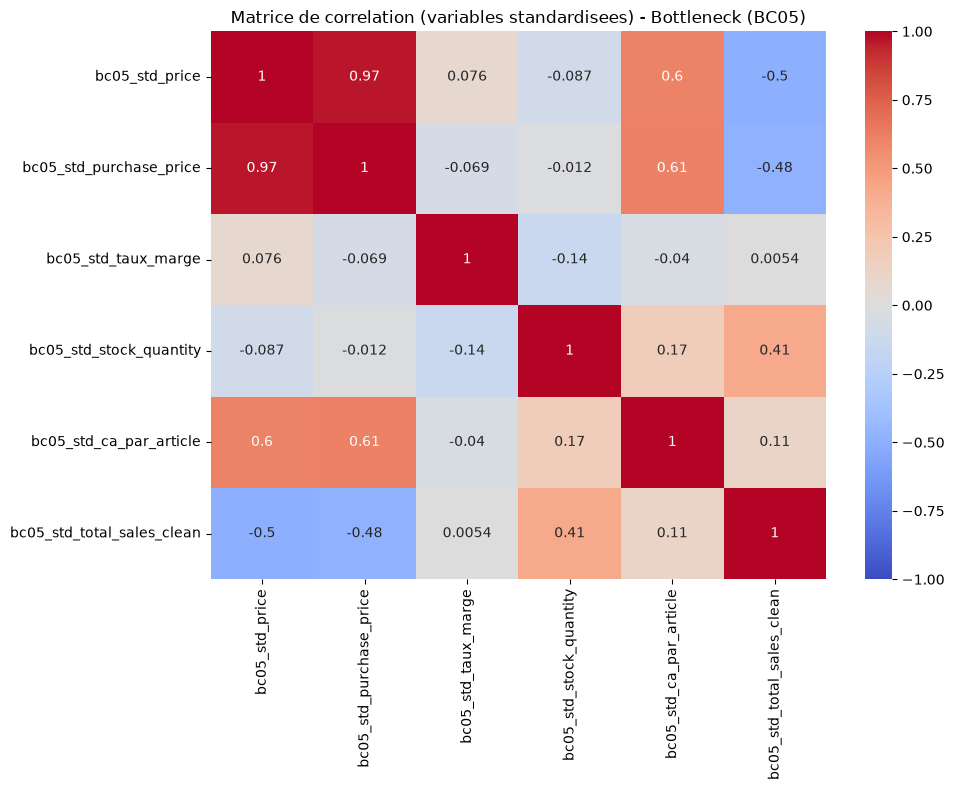

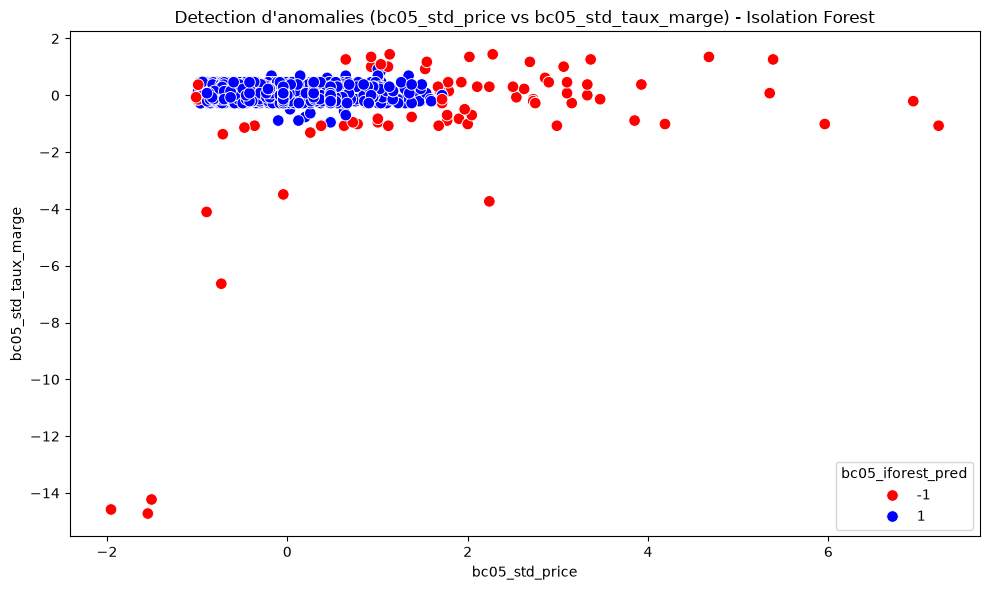

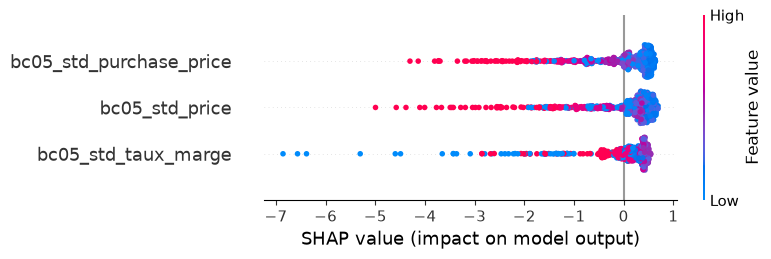

Isolation Forest simplifie calcule (avec variables standardisees).
- variables standardisees: ['price', 'purchase_price', 'taux_marge', 'stock_quantity', 'ca_par_article', 'total_sales_clean']
- features IF standardisees: ['bc05_std_price', 'bc05_std_purchase_price', 'bc05_std_taux_marge']
- alertes detectees: 82
- exports:
  output/bc05_iforest_corr_heatmap.png
  output/bc05_iforest_scatter_anomalies.png
  output/bc05_iforest_shap_summary.png
  output/bc05_iforest_alerts.csv


In [35]:
# 9.2 Code - Renfort BC05 : Isolation Forest (version simplifiee + variables standardisees)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import shap

if 'bc05_df' not in globals():
    raise RuntimeError("bc05_df introuvable. Executer d'abord la section 9.1.")

output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)
df = bc05_df.copy()

# Reconstitution des variables manquantes quand possible
if 'taux_marge' not in df.columns and 'taux_marge_pct' in df.columns:
    df['taux_marge'] = pd.to_numeric(df['taux_marge_pct'], errors='coerce') / 100.0

if 'taux_marge' not in df.columns and {'price', 'purchase_price'}.issubset(df.columns):
    price_num = pd.to_numeric(df['price'], errors='coerce')
    purchase_num = pd.to_numeric(df['purchase_price'], errors='coerce')
    df['taux_marge'] = np.where(purchase_num > 0, (price_num - purchase_num) / purchase_num, np.nan)

if 'total_sales_clean' not in df.columns:
    if 'total_sales' in df.columns:
        df['total_sales_clean'] = pd.to_numeric(df['total_sales'], errors='coerce')

if 'ca_par_article' not in df.columns:
    if 'price' in df.columns and 'total_sales_clean' in df.columns:
        df['ca_par_article'] = (
            pd.to_numeric(df['price'], errors='coerce')
            * pd.to_numeric(df['total_sales_clean'], errors='coerce')
        )

# Variables a standardiser (demande explicite BC05)
vars_to_standardize = [
    'price',
    'purchase_price',
    'taux_marge',
    'stock_quantity',
    'ca_par_article',
    'total_sales_clean',
]
available_vars = [c for c in vars_to_standardize if c in df.columns]

if len(available_vars) < 2:
    raise RuntimeError("Pas assez de variables disponibles pour standardisation/correlation.")

# 0) Standardisation commune pour la heatmap et la suite
base_df = df[available_vars].apply(pd.to_numeric, errors='coerce')
base_df = base_df.fillna(base_df.median(numeric_only=True))

scaler_all = StandardScaler()
std_array = scaler_all.fit_transform(base_df)
std_cols = [f'bc05_std_{c}' for c in available_vars]
std_df = pd.DataFrame(std_array, columns=std_cols, index=df.index)

# On expose les colonnes standardisees dans df et bc05_df
for col in std_cols:
    df[col] = std_df[col]
    bc05_df[col] = std_df[col]

# 1) Matrice de correlation sur variables standardisees
plt.figure(figsize=(10, 8))
sns.heatmap(
    std_df.corr(method='pearson'),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
)
plt.title('Matrice de correlation (variables standardisees) - Bottleneck (BC05)')
plt.tight_layout()
plt.savefig(output_dir / 'bc05_iforest_corr_heatmap.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close()

# 2) Isolation Forest sur variables standardisees
iforest_raw_candidates = ['price', 'purchase_price', 'taux_marge']
iforest_features = [f'bc05_std_{c}' for c in iforest_raw_candidates if c in available_vars]
if len(iforest_features) < 2:
    iforest_features = std_cols[: min(3, len(std_cols))]

X_scaled = df[iforest_features].to_numpy()

clf = IsolationForest(contamination=0.10, random_state=42)
clf.fit(X_scaled)

df['bc05_iforest_score'] = clf.decision_function(X_scaled)
df['bc05_iforest_pred'] = clf.predict(X_scaled)  # 1 normal, -1 anomalie
df['bc05_iforest_flag'] = df['bc05_iforest_pred'] == -1

bc05_df['bc05_iforest_score'] = df['bc05_iforest_score']
bc05_df['bc05_iforest_pred'] = df['bc05_iforest_pred']
bc05_df['bc05_iforest_flag'] = df['bc05_iforest_flag']

# 3) Scatter plot anomalies sur variables standardisees
x_col = 'bc05_std_price' if 'bc05_std_price' in df.columns else iforest_features[0]
y_col = 'bc05_std_taux_marge' if 'bc05_std_taux_marge' in df.columns else iforest_features[1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x=x_col,
    y=y_col,
    hue='bc05_iforest_pred',
    palette={1: 'blue', -1: 'red'},
    s=70,
)
plt.title(f"Detection d'anomalies ({x_col} vs {y_col}) - Isolation Forest")
plt.tight_layout()
plt.savefig(output_dir / 'bc05_iforest_scatter_anomalies.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close()

# 4) Explicabilite SHAP sur variables standardisees
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_scaled)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_scaled, feature_names=iforest_features, show=False)
plt.tight_layout()
plt.savefig(output_dir / 'bc05_iforest_shap_summary.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close()

# Export des alertes
id_col = 'product_id' if 'product_id' in df.columns else df.columns[0]
raw_export_cols = [c for c in vars_to_standardize if c in df.columns]
anomalies = df.loc[df['bc05_iforest_flag'], [id_col, 'bc05_iforest_score'] + raw_export_cols + iforest_features].copy()
anomalies.sort_values('bc05_iforest_score', ascending=True).to_csv(
    output_dir / 'bc05_iforest_alerts.csv',
    index=False,
    encoding='utf-8-sig',
)

print('Isolation Forest simplifie calcule (avec variables standardisees).')
print(f'- variables standardisees: {available_vars}')
print(f'- features IF standardisees: {iforest_features}')
print(f"- alertes detectees: {int(df['bc05_iforest_flag'].sum())}")
print('- exports:')
print('  output/bc05_iforest_corr_heatmap.png')
print('  output/bc05_iforest_scatter_anomalies.png')
print('  output/bc05_iforest_shap_summary.png')
print('  output/bc05_iforest_alerts.csv')

In [ ]:
# 9.2bis Code - Matrice decisionnelle calibree (IF + SHAP + impact pour Critique, kNN/K-Means pour surveillance)
# Objectif : produire une short-list stricte 'Critique' et une file 'A surveiller' sans laisser la rarete statistique seule declencher l'urgence metier.

import numpy as np
import pandas as pd
from pathlib import Path

if 'bc05_df' not in globals():
    raise RuntimeError("bc05_df introuvable. Executer d'abord la section 9.1/9.2.")

decision_df = bc05_df.copy()

required_cols = ['bc05_iforest_flag', 'bc05_iforest_score']
missing_cols = [c for c in required_cols if c not in decision_df.columns]
if missing_cols:
    raise RuntimeError(f"Colonnes manquantes pour la matrice decisionnelle: {missing_cols}")

# Normalisation robuste des signaux
decision_df['price'] = pd.to_numeric(decision_df.get('price'), errors='coerce')
decision_df['purchase_price'] = pd.to_numeric(decision_df.get('purchase_price'), errors='coerce')
decision_df['taux_marge'] = pd.to_numeric(decision_df.get('taux_marge'), errors='coerce')
decision_df['stock_quantity'] = pd.to_numeric(decision_df.get('stock_quantity'), errors='coerce')
decision_df['ca_par_article'] = pd.to_numeric(decision_df.get('ca_par_article'), errors='coerce')
decision_df['total_sales_clean'] = pd.to_numeric(
    decision_df.get('total_sales_clean', decision_df.get('total_sales')), errors='coerce',
)

# 1) Composante IF (plus le score est bas, plus c'est atypique)
if_score = pd.to_numeric(decision_df['bc05_iforest_score'], errors='coerce').fillna(0.0)
decision_df['if_component'] = (-if_score).rank(pct=True)

# 2) Composante SHAP (si disponible)
decision_df['shap_component'] = 0.0
decision_df['shap_top_driver'] = 'n/a'

if 'shap_values' in globals() and 'iforest_features' in globals():
    try:
        shap_arr = np.asarray(shap_values)
        if shap_arr.ndim == 2 and shap_arr.shape[0] == len(decision_df):
            shap_abs = np.abs(shap_arr)
            shap_strength = shap_abs.mean(axis=1)
            max_strength = np.nanmax(shap_strength) if np.nanmax(shap_strength) > 0 else 1.0
            decision_df['shap_component'] = np.clip(shap_strength / max_strength, 0, 1)

            feat_names = list(iforest_features)
            if shap_abs.shape[1] == len(feat_names):
                top_idx = shap_abs.argmax(axis=1)
                decision_df['shap_top_driver'] = [feat_names[i] for i in top_idx]
    except Exception as exc:
        print(f"SHAP non integre dans la matrice (fallback sans SHAP): {exc}")

# 3) Composante kNN : rarete locale, reservee a la surveillance
# Elle aide a classer les investigations mais ne suffit plus a rendre un produit Critique.
decision_df['knn_component'] = 0.0
if 'bc05_knn_score' in decision_df.columns:
    knn_score = pd.to_numeric(decision_df['bc05_knn_score'], errors='coerce')
    decision_df['knn_component'] = knn_score.rank(pct=True).fillna(0.0)
else:
    print("kNN indisponible dans bc05_df: composante knn_component=0")

# 4) Composante K-Means : distance + risque cluster, reservee a la surveillance
decision_df['kmeans_component'] = 0.0
if {'bc05_kmeans_centroid_distance', 'bc05_kmeans_cluster'}.issubset(decision_df.columns):
    dist = pd.to_numeric(decision_df['bc05_kmeans_centroid_distance'], errors='coerce')
    dist_component = dist.rank(pct=True).fillna(0.0)

    cluster_col = decision_df['bc05_kmeans_cluster']
    cluster_risk = decision_df.groupby(cluster_col)['bc05_iforest_flag'].transform('mean')
    cluster_risk = pd.to_numeric(cluster_risk, errors='coerce').fillna(0.0)
    if cluster_risk.max() > 0:
        cluster_risk = cluster_risk / cluster_risk.max()

    decision_df['kmeans_component'] = np.clip(0.7 * dist_component + 0.3 * cluster_risk, 0, 1)
else:
    print("K-Means indisponible dans bc05_df: composante kmeans_component=0")

# 5) Composante impact business
ca_norm = decision_df['ca_par_article'].fillna(0).clip(lower=0)
ca_q95 = ca_norm.quantile(0.95) if len(ca_norm) else 1
if not np.isfinite(ca_q95) or ca_q95 <= 0:
    ca_q95 = 1
decision_df['impact_ca_component'] = np.clip(ca_norm / ca_q95, 0, 1)

decision_df['impact_margin_flag'] = (decision_df['taux_marge'].fillna(0) < 0).astype(int)
decision_df['impact_rupture_flag'] = (
    (decision_df['stock_quantity'].fillna(0) <= 0)
    & (decision_df['total_sales_clean'].fillna(0) >= 3)
).astype(int)

decision_df['impact_component'] = (
    0.6 * decision_df['impact_ca_component']
    + 0.2 * decision_df['impact_margin_flag']
    + 0.2 * decision_df['impact_rupture_flag']
)

# 6) Deux scores separes pour eviter que la rarete statistique devienne une urgence metier.
weights_surveillance = {
    'if': 0.30,
    'knn': 0.20,
    'kmeans': 0.15,
    'shap': 0.10,
    'impact': 0.25,
}
weights_critical = {
    'if': 0.30,
    'shap': 0.10,
    'impact': 0.25,
}

surveillance_raw = (
    weights_surveillance['if'] * decision_df['if_component']
    + weights_surveillance['knn'] * decision_df['knn_component']
    + weights_surveillance['kmeans'] * decision_df['kmeans_component']
    + weights_surveillance['shap'] * decision_df['shap_component']
    + weights_surveillance['impact'] * decision_df['impact_component']
)
critical_raw = (
    weights_critical['if'] * decision_df['if_component']
    + weights_critical['shap'] * decision_df['shap_component']
    + weights_critical['impact'] * decision_df['impact_component']
)

decision_df['surveillance_score'] = surveillance_raw.clip(0, 1)
decision_df['critical_score'] = (critical_raw / sum(weights_critical.values())).clip(0, 1)
# Colonne historique conservee pour tri et compatibilite dashboard.
decision_df['decision_score'] = decision_df['surveillance_score']

critical_threshold = 0.65
watch_threshold = 0.45

critical_mask = decision_df['critical_score'] >= critical_threshold
watch_mask = decision_df['surveillance_score'] >= watch_threshold

decision_df['priorite_decisionnelle'] = 'Normal'
decision_df.loc[watch_mask, 'priorite_decisionnelle'] = 'A surveiller'
decision_df.loc[critical_mask, 'priorite_decisionnelle'] = 'Critique'

# 7) Motif de lecture strategique

def strategic_reason(row):
    if row['priorite_decisionnelle'] == 'Critique' and row['impact_rupture_flag'] == 1:
        return 'Critique strict - atypie IF expliquee + rupture avec demande'
    if row['priorite_decisionnelle'] == 'Critique' and row['impact_margin_flag'] == 1:
        return 'Critique strict - atypie IF expliquee + marge negative'
    if row['priorite_decisionnelle'] == 'Critique':
        return 'Critique strict - IF + SHAP + impact business'
    if row['priorite_decisionnelle'] == 'A surveiller':
        if row.get('knn_component', 0) >= 0.90:
            return 'A surveiller - rarete locale kNN elevee'
        if row.get('kmeans_component', 0) >= 0.90:
            return 'A surveiller - distance au cluster elevee'
        return 'A surveiller - signal statistique a confirmer'
    return 'Conforme au profil courant'


decision_df['lecture_strategique'] = decision_df.apply(strategic_reason, axis=1)

# 8) Validation Pandera avant export
PANDERA_DECISION_OK = False
try:
    import pandera.pandas as pa
    from pandera import Check

    schema = pa.DataFrameSchema({
        'priorite_decisionnelle': pa.Column(
            str,
            Check.isin(['Critique', 'A surveiller', 'Normal']),
            nullable=False,
        ),
        'decision_score': pa.Column(float, Check.in_range(0, 1), nullable=False),
        'critical_score': pa.Column(float, Check.in_range(0, 1), nullable=False),
        'surveillance_score': pa.Column(float, Check.in_range(0, 1), nullable=False),
        'if_component': pa.Column(float, Check.in_range(0, 1), nullable=False),
        'knn_component': pa.Column(float, Check.in_range(0, 1), nullable=False),
        'kmeans_component': pa.Column(float, Check.in_range(0, 1), nullable=False),
        'shap_component': pa.Column(float, Check.in_range(0, 1), nullable=False),
        'impact_component': pa.Column(float, Check.in_range(0, 1), nullable=False),
        'bc05_iforest_flag': pa.Column(bool, nullable=False),
        'lecture_strategique': pa.Column(str, nullable=False),
    }, strict=False)

    validated = schema.validate(
        decision_df[[
            'priorite_decisionnelle', 'decision_score', 'critical_score', 'surveillance_score',
            'if_component', 'knn_component', 'kmeans_component', 'shap_component', 'impact_component',
            'bc05_iforest_flag', 'lecture_strategique',
        ]]
    )
    PANDERA_DECISION_OK = True
    print(f"Validation Pandera OK: {len(validated):,} lignes")
except Exception as exc:
    print(f"Validation Pandera non bloquante (schema ou package): {exc}")

# 9) Export matrice pour dashboard
output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)

priority_cols = [
    'product_id', 'post_name', 'product_type',
    'priorite_decisionnelle', 'decision_score', 'critical_score', 'surveillance_score',
    'bc05_iforest_flag', 'bc05_iforest_score',
    'if_component', 'knn_component', 'kmeans_component', 'shap_component', 'impact_component',
    'shap_top_driver', 'lecture_strategique',
    'price', 'purchase_price', 'taux_marge', 'stock_quantity', 'total_sales_clean', 'ca_par_article',
]
priority_cols = [c for c in priority_cols if c in decision_df.columns]

decision_export = decision_df[priority_cols].copy()
decision_export = decision_export.sort_values(
    ['priorite_decisionnelle', 'decision_score'],
    ascending=[True, False],
    key=lambda s: s.map({'Critique': 0, 'A surveiller': 1, 'Normal': 2}) if s.name == 'priorite_decisionnelle' else s,
)

decision_export.to_csv(output_dir / 'bc05_matrice_decisionnelle.csv', index=False, encoding='utf-8-sig')
decision_export[decision_export['priorite_decisionnelle'].isin(['Critique', 'A surveiller'])].to_csv(
    output_dir / 'bc05_matrice_critique_surveillance.csv',
    index=False,
    encoding='utf-8-sig',
)

print("Matrice decisionnelle stricte exportee:")
print("- output/bc05_matrice_decisionnelle.csv")
print("- output/bc05_matrice_critique_surveillance.csv")
print("Ponderations surveillance:")
print(weights_surveillance)
print("Ponderations critique stricte:")
print(weights_critical)
print(f"Seuils -> Critique critical_score >= {critical_threshold:.2f} | A surveiller surveillance_score >= {watch_threshold:.2f}")
print("Repartition priorites:")
print(decision_export['priorite_decisionnelle'].value_counts(dropna=False).to_string())

Validation Pandera OK: 825 lignes
Matrice decisionnelle exportee:
- output/bc05_matrice_decisionnelle.csv
- output/bc05_matrice_critique_surveillance.csv
Ponderations utilisees:
{'if': 0.3, 'knn': 0.2, 'kmeans': 0.15, 'shap': 0.1, 'impact': 0.25}
Seuils calibres -> Critique >= 0.650 | A surveiller >= 0.450
Repartition priorites:
priorite_decisionnelle
Normal          652
A surveiller    142
Critique         31


## ⚠️ Points de vigilance (lecture BC05)

1. **Multicolinearite Prix vs Prix d'achat**  
La heatmap montre une correlation forte entre `bc05_std_price` et `bc05_std_purchase_price` (relation structurelle attendue).  
**Risque** : redondance d'information et instabilite des coefficients dans un modele explicatif.  
**Action recommandee** : privilegier `price` comme variable principale (plus actionnable cote pilotage commercial), ou passer par une regularisation/selection de variables.

2. **Interpretation prudente du taux de marge**  
Un coefficient proche de 0 avec les autres variables ne signifie pas "pas d'effet" : cela peut cacher une relation non lineaire ou l'impact de valeurs extremes.  
**Action recommandee** : completer l'analyse avec `Spearman`, puis controler les outliers de marge avant conclusion metier.

3. **Lien Stock ↔ Ventes : signal partiel**  
La correlation observee entre stock et ventes reste un signal d'association, pas une preuve de causalite.  
**Action recommandee** : tester une approche temporelle/causale (ex. Granger) et segmenter par famille produit/saisonnalite pour eviter les decisions globales trop rapides.

4. **Detection d'anomalies : priorisation, pas verdict automatique**  
Les alertes Isolation Forest (`bc05_iforest_flag`) doivent etre considerees comme une **file d'investigation priorisee**.  
**Action recommandee** : croiser chaque alerte avec le contexte metier (promotions, ruptures, changement de gamme, saisonnalite) avant action corrective.

## ✅ Decision operationnelle proposee

- Utiliser la heatmap standardisee pour identifier les variables redondantes.
- Garder un noyau de variables actionnables pour le suivi courant (`price`, `stock_quantity`, `ca_par_article`).
- Exploiter SHAP pour expliquer les alertes a fort impact business.
- Traiter en priorite les anomalies combinees : score IF faible + marge atypique + faible rotation.

<a id="RNCP37837BC05-KMEANS-KNN"></a>

## 9.3 Renfort BC05 - K-Means et kNN

<div style="font-size: 12px; color: #666; margin: 6px 0 2px 0;">
<strong>RNCP37837BC05 — Libelle :</strong> Segmentation et scoring de rarete pour orienter les actions commerciales et logistiques
</div>

Cette etape complete la detection par une lecture plus analytique:
- K-Means segmente les profils produits,
- kNN repere les points rares selon leur voisinage statistique.

In [36]:
# 9.3a Code - Renfort BC05 : K-Means non supervise
# Objectif : segmenter les profils produits avec un feature engineering centre sur la structure métier.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path

# Evite le bruit stderr joblib/loky sur certaines configurations Windows.
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 1))

if 'bc05_df' not in globals():
    raise RuntimeError("bc05_df introuvable. Exécuter d'abord la cellule 50 (BC05 immediate).")

try:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    SKLEARN_KMEANS_OK = True
except Exception as exc:
    SKLEARN_KMEANS_OK = False
    print(f"scikit-learn indisponible pour K-Means: {exc}")

if SKLEARN_KMEANS_OK:
    features = [c for c in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article'] if c in bc05_df.columns]
    if len(features) < 2:
        print("Colonnes insuffisantes pour K-Means.")
    else:
        work = bc05_df[features].apply(pd.to_numeric, errors='coerce')
        work = work.fillna(work.median(numeric_only=True))

        # Feature engineering K-Means : on conserve les variables métier brutes et on ajoute deux ratios lisibles.
        if 'price' in work.columns and 'stock_quantity' in work.columns:
            work['bc05_price_per_stock'] = np.where(work['stock_quantity'] > 0, work['price'] / work['stock_quantity'], 0)
        if 'price' in work.columns and 'taux_marge' in work.columns:
            work['bc05_price_margin_index'] = work['price'] * (1 + work['taux_marge'].fillna(0))
        kmeans_features = [c for c in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article', 'bc05_price_per_stock', 'bc05_price_margin_index'] if c in work.columns]
        work_kmeans = work[kmeans_features].copy()

        scaler = StandardScaler()
        X_kmeans = scaler.fit_transform(work_kmeans)

        n_rows = len(work)
        n_clusters = 3 if n_rows < 500 else 4

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(X_kmeans)
        bc05_df['bc05_kmeans_cluster'] = clusters

        # Distance au centroide du cluster affecte
        centers = kmeans.cluster_centers_
        centroid_dist = np.linalg.norm(X_kmeans - centers[clusters], axis=1)
        bc05_df['bc05_kmeans_centroid_distance'] = centroid_dist

        print("K-Means calcule.")
        print(f"- features K-Means: {kmeans_features}")
        print(f"- clusters: {n_clusters}")

        id_col = 'product_id' if 'product_id' in bc05_df.columns else bc05_df.columns[0]
        label_cols = [id_col] + [c for c in ['post_title', 'product_type'] if c in bc05_df.columns]
        kmeans_top = bc05_df.loc[:, label_cols + ['bc05_kmeans_cluster', 'bc05_kmeans_centroid_distance'] + [c for c in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article'] if c in bc05_df.columns]].copy()
        output_dir = Path('output')
        output_dir.mkdir(parents=True, exist_ok=True)

        fig_kmeans = px.scatter(
            bc05_df,
            x='price' if 'price' in bc05_df.columns else bc05_df.columns[0],
            y='stock_quantity' if 'stock_quantity' in bc05_df.columns else bc05_df.columns[1],
            color='bc05_kmeans_cluster',
            size='bc05_kmeans_centroid_distance',
            hover_name=id_col,
            title='BC05 - K-Means : segmentation des produits',
            labels={
                'price': 'Prix',
                'stock_quantity': 'Stock',
                'bc05_kmeans_cluster': 'Cluster',
                'bc05_kmeans_centroid_distance': 'Distance au centroide',
            },
        )
        fig_kmeans.update_layout(height=540, margin=dict(l=30, r=30, t=70, b=40))
        fig_kmeans.show()
        fig_kmeans.write_html(output_dir / 'bc05_kmeans_scatter.html', include_plotlyjs='cdn')
        try:
            fig_kmeans.write_image(output_dir / 'bc05_kmeans_scatter.png', width=1200, height=800, scale=2)
        except Exception as exc:
            print(f"Export PNG ignore (kaleido absent ou indisponible): {exc}")

        kmeans_top.sort_values('bc05_kmeans_centroid_distance', ascending=False).head(30).to_csv(output_dir / 'bc05_kmeans_alerts.csv', index=False, encoding='utf-8-sig')

K-Means calcule.
- features K-Means: ['price', 'stock_quantity', 'bc05_price_per_stock']
- clusters: 4


Export PNG ignore (kaleido absent ou indisponible): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



In [ ]:
# 9.3b Code - Renfort BC05 : kNN non supervise / rarete locale
# Objectif : scorer les produits rares selon leur voisinage statistique, sans variable cible supervisee.

import numpy as np
import pandas as pd
import plotly.express as px
from pathlib import Path

if 'bc05_df' not in globals():
    raise RuntimeError("bc05_df introuvable. Exécuter d'abord la cellule 50 (BC05 immediate).")

try:
    from sklearn.neighbors import NearestNeighbors
    from sklearn.preprocessing import StandardScaler
    SKLEARN_KNN_OK = True
except Exception as exc:
    SKLEARN_KNN_OK = False
    print(f"scikit-learn indisponible pour kNN: {exc}")

if SKLEARN_KNN_OK:
    features = [c for c in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article'] if c in bc05_df.columns]
    if len(features) < 2:
        print("Colonnes insuffisantes pour kNN.")
    else:
        work = bc05_df[features].apply(pd.to_numeric, errors='coerce')
        work = work.fillna(work.median(numeric_only=True))

        # Feature engineering kNN : on renforce la notion de voisinage avec des variables robustes et comparables.
        if 'price' in work.columns and 'stock_quantity' in work.columns:
            work['bc05_price_stock_balance'] = np.where(work['stock_quantity'] > 0, work['price'] / (work['stock_quantity'] + 1), 0)
        if 'ca_par_article' in work.columns and 'price' in work.columns:
            work['bc05_ca_price_ratio'] = np.where(work['price'] > 0, work['ca_par_article'] / work['price'], 0)
        knn_features = [c for c in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article', 'bc05_price_stock_balance', 'bc05_ca_price_ratio'] if c in work.columns]
        work_knn = work[knn_features].copy()

        scaler = StandardScaler()
        X_knn = scaler.fit_transform(work_knn)

        nn = NearestNeighbors(n_neighbors=min(6, len(work_knn)))
        nn.fit(X_knn)
        distances, _ = nn.kneighbors(X_knn)
        knn_score = distances[:, 1:].mean(axis=1) if distances.shape[1] > 1 else distances[:, 0]
        bc05_df['bc05_knn_score'] = knn_score
        knn_threshold = float(np.quantile(knn_score, 0.95))
        bc05_df['bc05_knn_flag'] = bc05_df['bc05_knn_score'] >= knn_threshold

        print("kNN calcule.")
        print(f"- features kNN: {knn_features}")
        print(f"- seuil kNN (95e percentile): {knn_threshold:.4f}")
        print(f"- alertes kNN: {int(bc05_df['bc05_knn_flag'].sum())}")

        id_col = 'product_id' if 'product_id' in bc05_df.columns else bc05_df.columns[0]
        knn_alerts = bc05_df.loc[bc05_df['bc05_knn_flag'], [id_col, 'bc05_knn_score'] + [c for c in ['price', 'taux_marge', 'stock_quantity', 'ca_par_article'] if c in bc05_df.columns]].copy()

        fig_knn = px.scatter(
            bc05_df,
            x='price' if 'price' in bc05_df.columns else bc05_df.columns[0],
            y='ca_par_article' if 'ca_par_article' in bc05_df.columns else bc05_df.columns[1],
            color='bc05_knn_flag',
            size='bc05_knn_score',
            hover_name=id_col,
            title='BC05 - kNN : rarete des produits selon le voisinage',
            labels={
                'price': 'Prix',
                'ca_par_article': 'CA par article',
                'bc05_knn_flag': 'Produit rare',
                'bc05_knn_score': 'Score kNN',
            },
        )
        fig_knn.update_layout(height=540, margin=dict(l=30, r=30, t=70, b=40))
        fig_knn.show()
        output_dir = Path('output')
        output_dir.mkdir(parents=True, exist_ok=True)
        fig_knn.write_html(output_dir / 'bc05_knn_scatter.html', include_plotlyjs='cdn')
        try:
            fig_knn.write_image(output_dir / 'bc05_knn_scatter.png', width=1200, height=800, scale=2)
        except Exception as exc:
            print(f"Export PNG ignore (kaleido absent ou indisponible): {exc}")

        knn_alerts.sort_values('bc05_knn_score', ascending=False).head(30).to_csv(output_dir / 'bc05_knn_alerts.csv', index=False, encoding='utf-8-sig')

kNN calcule.
- features kNN: ['price', 'stock_quantity', 'bc05_price_stock_balance']
- seuil kNN (95e percentile): 0.6280
- alertes kNN: 42


Export PNG ignore (kaleido absent ou indisponible): 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



### Conclusion technique et métier - kNN rareté locale (42 alertes)

**Lecture technique.** Le kNN utilisé ici est un scoring non supervisé de rareté locale : aucune variable cible n'est prédite. Les produits sont standardisés puis comparés à leurs plus proches voisins sur les variables `price`, `taux_marge`, `stock_quantity`, `ca_par_article` et deux ratios dérivés. Le score `bc05_knn_score` correspond à la distance moyenne aux voisins les plus proches ; plus il est élevé, plus le produit est isolé statistiquement. Le seuil retenu est le **95e percentile**, ce qui fait ressortir **42 produits rares** dans le catalogue.

**Lecture métier.** Ces 42 alertes ne sont pas des erreurs certaines : ce sont des références à auditer en priorité parce qu'elles ont un profil atypique par rapport au reste du catalogue. Elles peuvent correspondre à des produits premium légitimes, des ruptures avec demande, des niveaux de stock incohérents, des prix ou marges à valider, ou des cas commerciaux spécifiques. La bonne utilisation consiste à croiser ces alertes avec les résultats Isolation Forest, la matrice décisionnelle et les informations métier avant toute correction.

**Décision opérationnelle.** Les alertes kNN doivent alimenter une file de revue : vérifier d'abord les produits aussi signalés comme critiques ou à surveiller dans `bc05_matrice_decisionnelle.csv`, puis documenter la cause de l'atypie. Une alerte validée comme légitime doit être conservée comme exception métier ; une alerte liée à un prix, une marge ou un stock incohérent doit déclencher une correction dans les systèmes sources.

In [ ]:
# 9.3c - Synchronisation des dataviz BC05
# Objectif : centraliser les graphiques BC05 dans output/dataviz pour la publication portfolio.

from pathlib import Path
from shutil import copy2

if 'project_root' not in globals():
    cwd = Path.cwd().resolve()
    candidate_roots = [cwd, *cwd.parents]
    project_root = next(
        (
            root / 'Partie_1' / 'P6_ameliore_IA'
            for root in candidate_roots
            if (root / 'Partie_1' / 'P6_ameliore_IA').exists()
        ),
        cwd,
    )

bc05_source_candidates = [
    Path('output'),
    project_root / 'notebooks' / 'output',
]

bc05_dataviz_dir = project_root / 'output' / 'dataviz'
bc05_dataviz_dir.mkdir(parents=True, exist_ok=True)

visual_extensions = {'.html', '.png'}
synced_files = []

for source_dir in bc05_source_candidates:
    if not source_dir.exists():
        continue
    for source_file in source_dir.glob('bc05*'):
        if source_file.suffix.lower() not in visual_extensions:
            continue
        destination_file = bc05_dataviz_dir / source_file.name
        if source_file.resolve() == destination_file.resolve():
            continue
        copy2(source_file, destination_file)
        synced_files.append(destination_file.name)

synced_files = sorted(set(synced_files))
print('Synchronisation dataviz BC05 terminee.')
print(f'- Dossier cible : {bc05_dataviz_dir}')
print(f'- Visuels synchronises : {len(synced_files)}')
for filename in synced_files:
    print(f'  • {filename}')

In [ ]:
# CHECKPOINT FINAL - Exécution complète
# Objectif : confirmer que le notebook a exécuté avec succès de bout en bout,
# y compris le renfort BC05.

from pathlib import Path

print("\n" + "=" * 80)
print("🎯 CHECKPOINT FINAL - VALIDATION DE L'EXÉCUTION COMPLÈTE")
print("=" * 80)

execution_status = "✅ SUCCÈS" if 'df_final' in globals() and 'kpi_summary' in globals() else "⚠️  À vérifier"

print(f"\nStatut de l'exécution : {execution_status}")

# 1. Vérifier que toutes les phases ont été exécutées
print("\n📋 CHECKLIST D'EXÉCUTION :")
print("-" * 80)


def has_dataframe_columns(dataframe_name: str, required_columns: list[str]) -> bool:
    if dataframe_name not in globals():
        return False
    dataframe = globals()[dataframe_name]
    return all(column in dataframe.columns for column in required_columns)


output_dir = Path('output')
bc05_expected_exports = [
    output_dir / 'bc05_anomalies_summary.csv',
    output_dir / 'bc05_alertes_actionnables.csv',
    output_dir / 'bc05_iforest_alerts.csv',
    output_dir / 'bc05_kmeans_alerts.csv',
    output_dir / 'bc05_knn_alerts.csv',
    output_dir / 'bc05_matrice_decisionnelle.csv',
    output_dir / 'bc05_matrice_critique_surveillance.csv',
]

checklist = {
    "Phase I - Chargement données": 'df_final' in globals(),
    "Phase I - Contrôles qualité": 'quality_report' in globals(),
    "Phase I - Nettoyage stocks": 'stock_validation_report' in globals(),
    "Phase I - Rapprochement ERP/Web": 'merge_report' in globals(),
    "Phase II.1 - KPI Chiffre d'affaires": 'kpi_summary' in globals(),
    "Phase II.2 - Analyse Pareto": 'pareto_revenue' in globals(),
    "Phase II.3 - Anomalies de saisie": 'price_invalid' in globals() and 'negative_margins' in globals(),
    "Phase II.4 - Outliers prix": 'price_outliers_iqr' in globals(),
    "Phase II.5 - Stocks et marges": 'stock_margin_summary' in globals(),
    "Phase II.6 - Corrélations": 'correlation_matrix' in globals(),
    "BC05 9.1 - Alertes Z-score/IQR": 'bc05_summary' in globals() and 'bc05_alerts_actionnables' in globals(),
    "BC05 9.2 - Isolation Forest": has_dataframe_columns('bc05_df', ['bc05_iforest_score', 'bc05_iforest_flag']),
    "BC05 9.2bis - Matrice décisionnelle": 'decision_export' in globals() and has_dataframe_columns('decision_df', ['priorite_decisionnelle', 'decision_score']),
    "BC05 9.3a - K-Means": has_dataframe_columns('bc05_df', ['bc05_kmeans_cluster', 'bc05_kmeans_centroid_distance']),
    "BC05 9.3b - kNN rareté locale": has_dataframe_columns('bc05_df', ['bc05_knn_score', 'bc05_knn_flag']),
    "BC05 - Exports principaux": all(path.exists() for path in bc05_expected_exports),
}

completed_items = 0
for item, is_completed in checklist.items():
    symbol = "✅" if is_completed else "❌"
    print(f"  {symbol} {item}")
    if is_completed:
        completed_items += 1

completion_rate = (completed_items / len(checklist) * 100)
print(f"\nTaux de complétude : {completion_rate:.0f}% ({completed_items}/{len(checklist)} étapes)")

# 2. Résumer les données finales
print("\n📊 DONNÉES FINALES DISPONIBLES :")
print("-" * 80)

if 'df_final' in globals():
    print(f"  📊 DataFrame final               : {df_final.shape[0]:,} lignes × {df_final.shape[1]} colonnes")

if 'bc05_summary' in globals():
    try:
        n_alerts = int(bc05_summary.loc[bc05_summary['indicateur'] == 'nb_alertes', 'valeur'].iloc[0])
        alert_rate = float(bc05_summary.loc[bc05_summary['indicateur'] == 'taux_alertes_pct', 'valeur'].iloc[0])
        print(f"  🚨 Alertes BC05 immédiates       : {n_alerts} ({alert_rate:.2f}%)")
    except Exception:
        print("  🚨 Alertes BC05 immédiates       : résumé disponible, lecture détaillée à vérifier")

if 'bc05_df' in globals() and 'bc05_iforest_flag' in bc05_df.columns:
    print(f"  🌲 Alertes Isolation Forest      : {int(bc05_df['bc05_iforest_flag'].sum())}")

if 'bc05_df' in globals() and 'bc05_kmeans_cluster' in bc05_df.columns:
    print(f"  🧩 Clusters K-Means              : {bc05_df['bc05_kmeans_cluster'].nunique()}")

if 'bc05_df' in globals() and 'bc05_knn_flag' in bc05_df.columns:
    print(f"  📍 Alertes kNN rareté locale     : {int(bc05_df['bc05_knn_flag'].sum())}")

if 'decision_export' in globals() and 'priorite_decisionnelle' in decision_export.columns:
    print("  🎯 Priorités décisionnelles      :")
    for priority, count in decision_export['priorite_decisionnelle'].value_counts(dropna=False).items():
        print(f"      • {priority}: {count}")

if 'output_dataviz_dir' in globals():
    try:
        dataviz_files = list(output_dataviz_dir.glob("*.html")) if hasattr(output_dataviz_dir, 'glob') else []
        print(f"  📈 Graphiques Phase II générés   : {len(dataviz_files)} fichiers HTML")
    except Exception:
        print("  📈 Graphiques Phase II           : dossier output/dataviz/ inaccessible")

existing_bc05_exports = [path.name for path in bc05_expected_exports if path.exists()]
print(f"  📁 Exports BC05 principaux       : {len(existing_bc05_exports)}/{len(bc05_expected_exports)} fichiers")

# 3. Avertissements si nécessaire
print("\n" + "-" * 80)

if completion_rate < 100:
    print("⚠️  ATTENTION :")
    print("   Certaines étapes n'ont pas été exécutées ou certains exports sont manquants.")
    print("   Relancer le notebook de bout en bout, puis vérifier les cellules BC05 9.1 à 9.3.")
else:
    print("✅ TOUS LES CONTRÔLES PASSENT")

print("\n" + "=" * 80)


In [ ]:
# EXÉCUTION FINALE - Temps total et statut global
print("\n" + "=" * 80)
print("⏱️  TEMPS D'EXÉCUTION TOTAL DU NOTEBOOK")
print("=" * 80)

elapsed_time = notebook_elapsed_time()

print("\n🎉 RÉSUMÉ FINAL :")
print("-" * 80)
print(f"  ⏱️  Temps d'exécution total   : {elapsed_time}")
print(f"  📊 Nombre d'étapes complétées : {completed_items}/{len(checklist)}")
print(f"  ✅ Statut final              : {execution_status}")
print("\n" + "=" * 80)
print("Le notebook est prêt pour restitution au CODIR.")
print("Voir docs/GUIDE_EXECUTION_NOTEBOOK.md pour utilisation et interprétation.")
print("=" * 80 + "\n")